# This script runs ordinal Sustain with the following details (3/26/2026)

### It imports data_Tau_trimmed6_abc.csv which is an input set that is expanded due to filtering by the new ABC scoring criteria instead of by Reagan score. There are no missing values, non-AD ABC scores are exlcuded

## Quick(er) Analysis: outputs H clustered PVD & Vital Sustain Post analysis when running full script

## no cross validation, extra post analysis, brain painter, etc (check v7 for this)

## Load libraries

In [1]:
import sys #import the local edited python file 
sys.path.insert(0, '/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1')
import pySuStaIn
from pySuStaIn import OrdinalSustain
import numpy as np
import os
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
import pickle
import sklearn.model_selection
import pandas as pd
from matplotlib.patches import Patch
import seaborn as sns
import pylab
print(pySuStaIn.__file__)

/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1/pySuStaIn/__init__.py


## Define Data Likelihood, Output Folder, N_S_max

In [2]:
# Defining key variables up here for ease of running!

#Output folder
output_folder = "./sustain_output54"

# Data Likelihood values
high_prob = 0.9  # if subject is normal (score 0) # ///ADJUSTING////, previously 0.80
low_prob = 0.05  # if subject is not normal, previously 0.10

# Max subtypes to fit
N_S_max = 3 #CHECK

## Taking a look at the imported data

In [3]:
#Import the cleaned data

# ////nonAD INCLUDED //// 
#This is the set with the non AD patients included
#data = pd.read_csv("data_Tau_trimmed5.csv")
#data_og = data #saving for later
#dataset_name = "data_Tau_trimmed5.csv"

# ////nonAD EXCLUDED ////
# this set removes the non AD patients
#data = pd.read_csv("data_Tau_trimmed5_notAD.csv")
data = pd.read_csv("data_Tau_trimmed6_notAD_abc.csv")
data_og = data #saving for later
dataset_name = "data_Tau_trimmed6_notAD_abc.csv"

#double check here: EXCLUDE all 

#check the loaded data
display(data.head(5))
display(data.shape)

,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,Tau SQ Olfactory Bulbs,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala,Tau SQ Substantia innominate,Tau SQ Globus pallidus
0,BVAX029,No,NaN,82,Male,2.0,3.0,3.0,2.0,2.0,3.0,3.0,1.0,1.0,3.0,3.0,3.0,0.0
1,BVAX056,No,NaN,89,Female,1.0,0.0,1.0,0.0,0.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,0.0
2,BVAX057,No,NaN,95,Female,1.0,2.0,2.0,1.0,0.0,1.0,2.0,2.0,2.0,3.0,3.0,2.0,0.0
3,BVAX060,No,NaN,68,Female,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0
4,BVAX062,No,NaN,93,Female,2.0,2.0,3.0,3.0,2.0,1.0,3.0,1.0,2.0,3.0,3.0,3.0,0.0


(301, 18)

## ID the 13 regions of interest

In [4]:
#need to select the 10 regions to retain manually:
# Get the column names from column 5 onward (index 5 to the end)
selected_regions = data.columns[5:].tolist()

#show them to confirm
print("Selected regions:", selected_regions)

#check the loaded data
display(data.head(5))
display(data.shape)


Selected regions: ['NFT Tau SQ dorsolateral middle frontal', 'NFT Tau SQ inferior parietal', 'NFT Tau SQ superior temporal', 'NFT Tau SQ Calcarine', 'NFT Tau SQ substantia nigra', 'Tau SQ Olfactory Bulbs', 'NFT Tau SQ CA1', 'NFT Tau SQ CA2', 'NFT Tau SQ CA4', 'NFT Tau SQ entorhinal cortex', 'NFT Tau SQ amygdala', 'Tau SQ Substantia innominate', 'Tau SQ Globus pallidus']


,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,Tau SQ Olfactory Bulbs,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala,Tau SQ Substantia innominate,Tau SQ Globus pallidus
0,BVAX029,No,NaN,82,Male,2.0,3.0,3.0,2.0,2.0,3.0,3.0,1.0,1.0,3.0,3.0,3.0,0.0
1,BVAX056,No,NaN,89,Female,1.0,0.0,1.0,0.0,0.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,0.0
2,BVAX057,No,NaN,95,Female,1.0,2.0,2.0,1.0,0.0,1.0,2.0,2.0,2.0,3.0,3.0,2.0,0.0
3,BVAX060,No,NaN,68,Female,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0
4,BVAX062,No,NaN,93,Female,2.0,2.0,3.0,3.0,2.0,1.0,3.0,1.0,2.0,3.0,3.0,3.0,0.0


(301, 18)

## Now drop to just 10 regions
## Exclude globus pallidus, olfactory, substantial innomita   

In [5]:
# in the above 'data' exclude the columns Tau SQ Substantia innominate, Tau SQ Olfactory Bulbs, and Tau SQ Globus pallidus
cols_to_exclude = [
    "Tau SQ Substantia innominate",
    "Tau SQ Olfactory Bulbs",
    "Tau SQ Globus pallidus"
]

data = data.drop(columns=cols_to_exclude, errors='ignore')

#new biomarker list (shorter)
biomarkers = data.columns[5:].tolist()

display(data.head())
display(data.shape)

,Case ID,RHI Exposure,Pathologic Group,Donor age at death,gender,NFT Tau SQ dorsolateral middle frontal,NFT Tau SQ inferior parietal,NFT Tau SQ superior temporal,NFT Tau SQ Calcarine,NFT Tau SQ substantia nigra,NFT Tau SQ CA1,NFT Tau SQ CA2,NFT Tau SQ CA4,NFT Tau SQ entorhinal cortex,NFT Tau SQ amygdala
0,BVAX029,No,NaN,82,Male,2.0,3.0,3.0,2.0,2.0,3.0,1.0,1.0,3.0,3.0
1,BVAX056,No,NaN,89,Female,1.0,0.0,1.0,0.0,0.0,3.0,2.0,1.0,3.0,3.0
2,BVAX057,No,NaN,95,Female,1.0,2.0,2.0,1.0,0.0,2.0,2.0,2.0,3.0,3.0
3,BVAX060,No,NaN,68,Female,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
4,BVAX062,No,NaN,93,Female,2.0,2.0,3.0,3.0,2.0,3.0,1.0,2.0,3.0,3.0


(301, 15)

## Optional: Drop the folks who might have another neurodegenerative disease (not AD, not a control)

In [7]:
# drop all patients that have (not AD, not a control)
##load the case_IDs that match this
#noncontrol_notAD_caseIDs = pd.read_csv("noncontrol_notAD_caseIDs.csv")

## Ensure Case_IDs are strings for a safe comparison
#noncontrol_notAD_caseIDs["Case ID"] = noncontrol_notAD_caseIDs["Case ID"].astype(str)

# Drop rows in 'data' that match these Case_IDs
# Make a copy to avoid modifying original
#data_filtered = data.copy()

# Ensure 'Case ID' column is string
#data_filtered["Case ID"] = data_filtered["Case ID"].astype(str)

# Filter out rows where Case ID is in noncontrol_notAD_caseIDs
#data_filtered = data_filtered[~data_filtered["Case ID"].isin(noncontrol_notAD_caseIDs["Case ID"])]

# -------------------------------
# Check the shape after filtering
# -------------------------------
#print(f"Original dataset shape: {data.shape}")
#print(f"Filtered dataset shape: {data_filtered.shape}")

#now return the filtered set to 'data' to keep consistency...
#data = data_filtered

#repeat the analysis...

### Optional: filter out control group 

In [8]:
# -------------------------------
# Filter out all CONTROL cases
# -------------------------------

# Make a copy for safety
#data_filtered = data.copy()

# Ensure the column is treated as string
#data_filtered["Pathologic Group"] = data_filtered["Pathologic Group"].astype(str)

# Remove rows where Pathologic Group == "Control"
#data_filtered = data_filtered[
#    data_filtered["Pathologic Group"].str.strip().str.lower() != "control"
#]

# -------------------------------
# Check shape before/after
# -------------------------------
#print(f"Original dataset shape: {data.shape}")
#print(f"Filtered dataset shape (controls removed): {data_filtered.shape}")

# -------------------------------
# Replace original dataset
# -------------------------------
#data = data_filtered


## SuStaIn Initialization

In [6]:
#here are the instructions in the ordinal model which could be of assistance
# The initializer for the scored events model implementation of AbstractSustain
        # Parameters:
        #   prob_nl                     - probability of negative/normal class for all subjects across all biomarkers 
        #                                 dim: number of subjects x number of biomarkers
        #   prob_score                  - probability of each score for all subjects across all biomarkers
        #                                 dim: number of subjects x number of biomarkers x number of scores
        #   score_vals                  - a matrix specifying the scores for each biomarker
        #                                 dim: number of biomarkers x number of scores
        #   biomarker_labels            - the names of the biomarkers as a list of strings
        #   N_startpoints               - number of startpoints to use in maximum likelihood step of SuStaIn, typically 25
        #   N_S_max                     - maximum number of subtypes, should be 1 or more
        #   N_iterations_MCMC           - number of MCMC iterations, typically 1e5 or 1e6 but can be lower for debugging
        #   output_folder               - where to save pickle files, etc.
        #   dataset_name                - for naming pickle files
        #   use_parallel_startpoints    - boolean for whether or not to parallelize the maximum likelihood loop
        #   seed                        - random number seed

# Initialize Ordinal SuStaIn

In [7]:
#Initialize Ordinal SuStaIn
#Determine dimensions
n_biomarkers = 10 #manually putting this in
n_subtypes = 3 #this is the max sustain will try to fit
n_scores = 3 #scores: 1, 2, 3        # The scores range from 0-3 but the score_vals are only 1,2,3 (0 doesnt count as a score)
n_subjects = data.shape[0]

#rename for consistency with previous version
data_selected = data

#check data types
display(data.dtypes)

#Assign just the biomarker data as X
X = data_selected.iloc[:, 5:15].to_numpy() #only the data after the first 5 columns is biomaker data
X = np.round(X).astype(int)            # round floats and convert scores to integer

#debug check to see max scores are <= 3; 4 unique scores
print("Unique scores in X:", np.unique(X))

#Define scores as discrete values
#DO NOT include scores that I consider to be ’normal’ (ie score of 0)
score_vals = np.arange(1, n_scores + 1)  # [1,2,3]
score_vals = np.tile(score_vals, (n_biomarkers, 1))  # shape (13,3)
#score_vals = np.tile(np.array([1, 2, 3]), (n_biomarkers, 1))  # shape: (, 3)

# /// prob_nl: (previously thought to be the prior) /// :::
#LIKELIHOOD of score of 0: 

#You can either: 
#   1] use a uniform random prior normallized over severity levels; 
#   2] representative prior based on distribution of input data scores
#Normalizing across subjects for each biomarker is wrong!!
#Fraction of subjects with severity 0 for each biomarker
#fraction_zero = np.array([(data[b] == 0).mean() for b in selected_regions])
# Repeat for all subjects
#prob_nl = np.tile(fraction_zero, (n_subjects, 1))

# /// ADJUSTED prob_nl /////
#prob_nl should correspond to the probability of a score of 0 
#(it is not a prior, individuals with a score of 0 should be assigned a high probability of scoring 0)
#Define prob_nl: P(normal) for each subject and biomarker: 
#loop through the data_selected  (subjects x biomarkers) and 
# assign a high probability of 0.8 for the coresponding index in prob_nl if the value is 0 (ie normal) in data_selected. 
# Otherwise give a low probability ie 0.1

# Initialize prob_nl
prob_nl = np.zeros((n_subjects, n_biomarkers))

#wait make sure to go through the X matrix not 'data_selected' which includes the 5 info columns!!!

# Assign probabilities based on observed score  ///ADJUSTING////
# high and low_prob are assigned above

for i in range(n_subjects):
    for j in range(n_biomarkers):
        if X[i, j] == 0:
            prob_nl[i, j] = high_prob
        else:
            prob_nl[i, j] = low_prob

#none of these values should be 0 
#from Alex: You will likely run into issues if you set any probabilities to 0 as then you will get multiplying by 0 causing numerical divide by 0 problems, 
# so I would recommend that as a minimum you have probabilities of 0.001

#////// ADJUSTED prob_score /////// 
#LIKELIHOOD of scores 1,2,3: 

#Define prob_score: p(score | biomarker) for each subject
#prob_score should then correspond to the probabilities of scores 1, 2, and 3
prob_score = np.full((n_subjects, n_biomarkers, n_scores), low_prob)  # initialize with low_prob
# Loop through scores 1, 2, 3
for s in range(1, 4):
    # Loop over subjects and biomarkers
    for i in range(n_subjects):
        for j in range(n_biomarkers):
            if X[i, j] == s:
                prob_score[i, j, s-1] = high_prob #give a high likelihood of observing the score if the desired score is found in the data set

# Assign low probability to all other slots that remain 0
prob_score[prob_score == 0] = low_prob #ie the subject x biomarker x score pairs that are not observed in the data 

#From Alex: You should be aware that if you set very high confidence in the scores (e.g. 0.999) 
# you will get a lot of subtypes as effectively this means that if even one person doesn’t match 
# the sequence their data will become very unlikely and a new subtype will need to be made. 
# I rarely set the highest probability to greater than 0.8

# Biomarker labels
biomarker_labels = data_selected.columns[5:15].tolist()
print(biomarker_labels)

#Output directory - can change this to save multiple outputs
#output_folder defined above
os.makedirs(output_folder, exist_ok=True)

#debug
print(np.shape(prob_nl))
print(np.shape(prob_score))
print(np.shape(score_vals))
print(n_biomarkers)

#make sure everything has the correct dimensions!
assert prob_nl.shape == (n_subjects, n_biomarkers), "Shape mismatch in prob_nl"
#assert prob_score_cases.shape == (n_subjects_cases, n_biomarkers, n_scores), "Shape mismatch in prob_score"
print("Number of biomarkers:", len(score_vals))
print("Scores for first biomarker:", score_vals[0])
#check that no prob_nl values are 0 
display(f"Minimum value in prob_nl: {prob_nl.min()}")

Case ID                                    object
RHI Exposure                               object
Pathologic Group                           object
Donor age at death                          int64
 gender                                    object
NFT Tau SQ dorsolateral middle frontal    float64
NFT Tau SQ inferior parietal              float64
NFT Tau SQ superior temporal              float64
NFT Tau SQ Calcarine                      float64
NFT Tau SQ substantia nigra               float64
NFT Tau SQ CA1                            float64
NFT Tau SQ CA2                            float64
NFT Tau SQ CA4                            float64
NFT Tau SQ entorhinal cortex              float64
NFT Tau SQ amygdala                       float64
dtype: object

Unique scores in X: [0 1 2 3]
['NFT Tau SQ dorsolateral middle frontal', 'NFT Tau SQ inferior parietal', 'NFT Tau SQ superior temporal', 'NFT Tau SQ Calcarine', 'NFT Tau SQ substantia nigra', 'NFT Tau SQ CA1', 'NFT Tau SQ CA2', 'NFT Tau SQ CA4', 'NFT Tau SQ entorhinal cortex', 'NFT Tau SQ amygdala']
(301, 10)
(301, 10, 3)
(10, 3)
10
Number of biomarkers: 10
Scores for first biomarker: [1 2 3]


'Minimum value in prob_nl: 0.05'

## Check the prob_nl values to ensure they make sense

In [8]:
#now check the results a couple times 
print("Shape of prob_nl (probability of normal (0) biomarker for each subject):", prob_nl.shape)

print("prob_nl check: Example row (fourth subject) to take a normal score of 0 for each biomarker:", prob_nl[3, :])

#Print the probabilities for the first subject
print("prob_score check: Probabilities for the second subject to take score of 1 for each biomarker:", prob_score[1, :, 0], "(Probabilities of being severity level = 1 for each biomarker)")


Shape of prob_nl (probability of normal (0) biomarker for each subject): (301, 10)
prob_nl check: Example row (fourth subject) to take a normal score of 0 for each biomarker: [0.9  0.9  0.05 0.9  0.9  0.05 0.05 0.9  0.05 0.05]
prob_score check: Probabilities for the second subject to take score of 1 for each biomarker: [0.9  0.05 0.9  0.05 0.05 0.05 0.05 0.9  0.05 0.05] (Probabilities of being severity level = 1 for each biomarker)


# Run SuStaIn (takes some time)

In [9]:
#Initialize model with the above defined values 
sustain_input = OrdinalSustain(
    dataset_name=dataset_name,        #already assigned at the very top
    N_S_max=N_S_max,                                 # 3clusters!     #this is max number of cluster groups (subtypes) to attempt to fit. number of subtypes output = N_S_max - 1 
    prob_nl=prob_nl,                              #PRIOR: probability is the frequency of each observed score
    prob_score=prob_score,                        #LIKELIHOOD: p(score | biomarker) 
                                      #This is a hard assignment i.e. we trust the data and theres no in between scores
    score_vals=score_vals,                              #THRESHOLDS: biomarker levels are 1,2,3
    biomarker_labels=biomarker_labels,                  #these are just the names of the brain regions 
    N_startpoints=5,                                    #avoids local optima in the finding the LL
    N_iterations_MCMC = int(1e4),                       #reasonable number of runs to 'find' most probable sequences (1e4 for quick analysis)
    output_folder=output_folder,
    use_parallel_startpoints=False) #this could be useful on the SCC... across many cores

#//RUN IT//
prob_subtype_stage  = sustain_input.run_sustain_algorithm() #this will run the algorithm

Found pickle file: ./sustain_output54/pickle_files/data_Tau_trimmed6_notAD_abc.csv_subtype0.pickle. Using pickled variables for 0 subtype.
Found pickle file: ./sustain_output54/pickle_files/data_Tau_trimmed6_notAD_abc.csv_subtype1.pickle. Using pickled variables for 1 subtype.
Found pickle file: ./sustain_output54/pickle_files/data_Tau_trimmed6_notAD_abc.csv_subtype2.pickle. Using pickled variables for 2 subtype.


## Check Model performance at each subtype 'split' with MCMC trace, Likelihood analysis

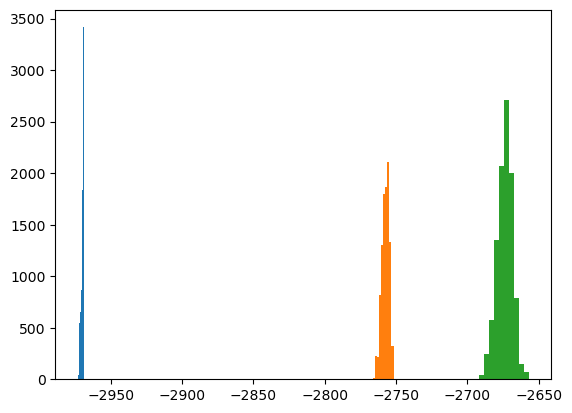

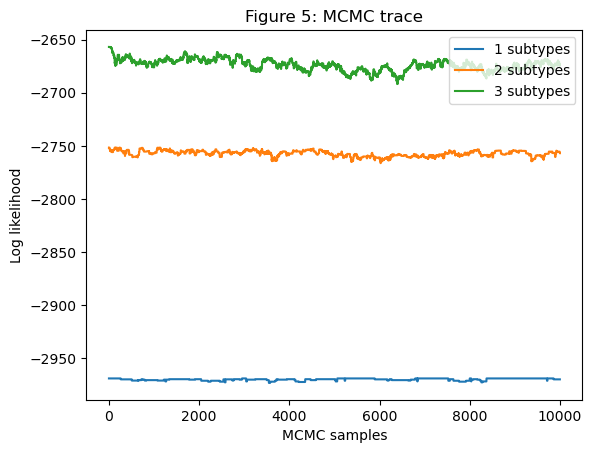

/var/folders/yq/blfjj9vn7vvf5tt08v98q_qr0000gn/T/ipykernel_63871/1873400349.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _ = plt.legend(loc='upper right')


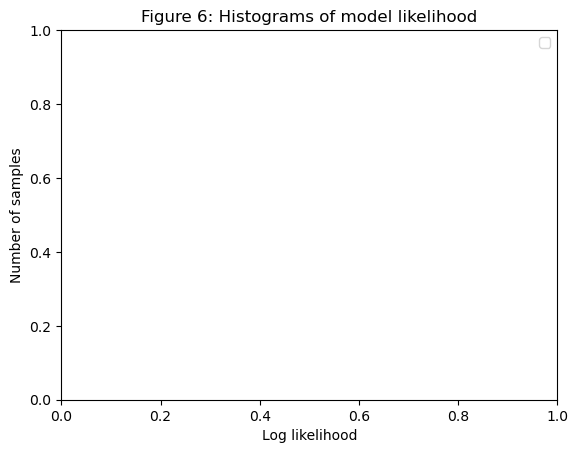

In [10]:
# check MCMC output
# go through each subtypes model and plot MCMC samples of the likelihood

for s in range(sustain_input.N_S_max):
    pickle_filename_s           = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pickle_filepath             = Path(pickle_filename_s)
    pickle_file                 = open(pickle_filename_s, 'rb')
    loaded_variables            = pickle.load(pickle_file)
    samples_likelihood          = loaded_variables["samples_likelihood"]
    pickle_file.close()

    _ = plt.figure(0)
    _ = plt.plot(range(sustain_input.N_iterations_MCMC), samples_likelihood, label= str(s+1) + " subtypes")
    _ = plt.figure(1)
    _ = plt.hist(samples_likelihood, label="subtype" + str(s))
    
_ = plt.figure(0)
_ = plt.legend(loc='upper right')
_ = plt.xlabel('MCMC samples')
_ = plt.ylabel('Log likelihood')
_ = plt.title('Figure 5: MCMC trace')
#save each of the figures below to a png: 

save_path = os.path.join(output_folder, "MCMC_trace.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight") #looks like by adjusting (increasing) this dpi you can increase the contrast level
plt.show()
    
_ = plt.figure(1)
_ = plt.legend(loc='upper right')
_ = plt.xlabel('Log likelihood')  
_ = plt.ylabel('Number of samples')  
_ = plt.title('Figure 6: Histograms of model likelihood')

#the legend shows the different split values 

# Step by step interpretation of the PVD inputs

In [12]:
#-----plot positional variance diagrams to interpret the subtype progressions-----
#///made lots of adjustments here....///

#optimal is ~2 subtypes from above determination so lets take a look at that
s = N_S_max - 1 #2 splits = 3 subtypes 
M = len(data) 

#Load the stored pickle
pickle_filename_s = f"{output_folder}/pickle_files/{dataset_name}_subtype{s}.pickle"
pk = pd.read_pickle(pickle_filename_s)
print(pickle_filename_s)

#need to define this for the PVD to run!!
samples_sequence = pk["samples_sequence"]
samples_f = pk["samples_f"]

print("\nThe shape of the samples sequence:", samples_sequence.shape)
print("\nThe shape of the samples sequence for subtype 1:", samples_sequence.shape[1:3])

#for example, [ 0 (subtype1), : (all stages), 1 (the first squence of biomarkers) ]
# this will give a 2D array of one of the predicted biomarker sequence orders: 
# To be able to predict severity too, we have to make the # of stages = possible events = biomarkers * severities
# each number in the squence below represents a unique biomarker and severity level

print("\nThe sample sequence for the first sequence of the first subtype:", samples_sequence[0,:,1])


#the samples_f is the posterior probability that this particular squence belongs to either subtype 1 or 2 
#membership fraction across samples of mcmc that follow either one of the sample squences in subtype 1 or one of the sequences in subtype 2
print("\nThe shape of samples_f:", samples_f.shape)
print("\nThe shape of the samples_f for subtype 1:", samples_f.shape[1:2])
#this is what gives the shading!
print("\nThe samples_f--The probability the 50th sequence belongs to subtype 1:", samples_f[0,49])
print("\nThe samples_f--The probability the 50th sequence belongs to subtype 2 (i.e. 1-above):", samples_f[1,49])

#check should add to one
#print(samples_f[1,499]+samples_f[0,499])


./sustain_output54/pickle_files/data_Tau_trimmed6_notAD_abc.csv_subtype2.pickle

The shape of the samples sequence: (3, 30, 10000)

The shape of the samples sequence for subtype 1: (30, 10000)

The sample sequence for the first sequence of the first subtype: [ 8.  5.  9.  2.  4.  6.  7.  0.  1. 16. 18. 15. 12. 19. 25. 28. 17. 29.
 22. 11. 10. 14. 20. 21.  3. 13. 26. 27. 23. 24.]

The shape of samples_f: (3, 10000)

The shape of the samples_f for subtype 1: (10000,)

The samples_f--The probability the 50th sequence belongs to subtype 1: 0.40423410691716327

The samples_f--The probability the 50th sequence belongs to subtype 2 (i.e. 1-above): 0.2932790540586427


# PVD Plotting Function

## Plot PVD using OrdinalSustain's plotting function

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21500000000000008..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.01440000000000008..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4214..1.0].


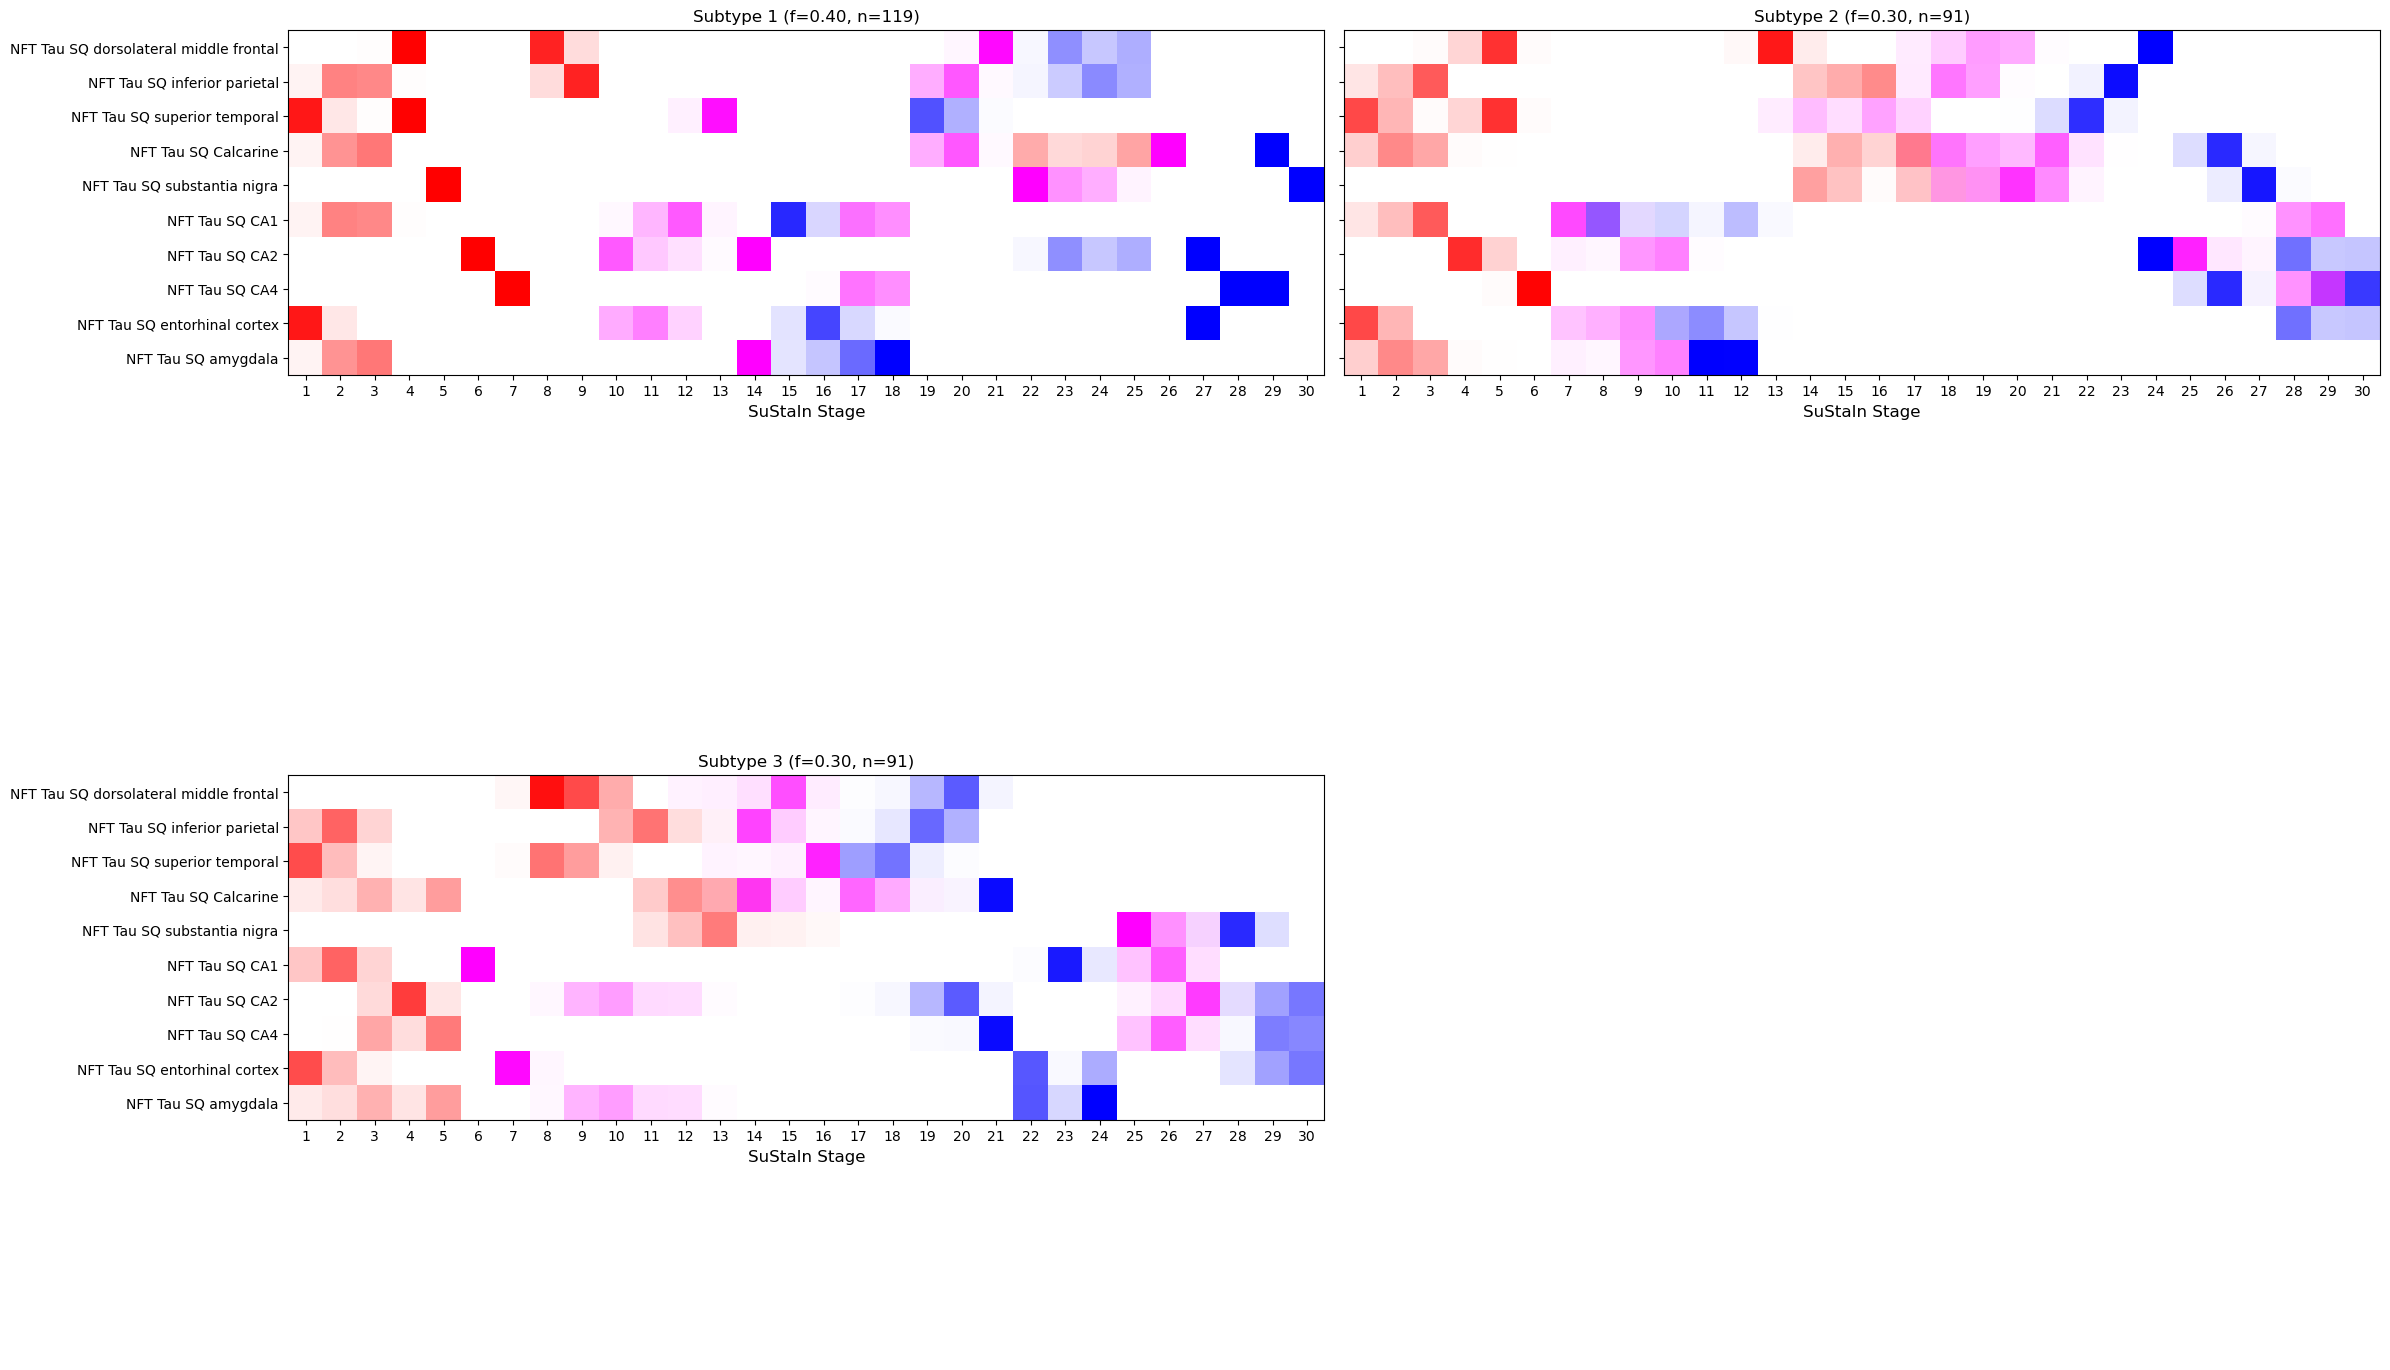

In [13]:
#-----Plot PVD using OrdinalSustain's plotting function-----
# sustain expands the labels and scores interally so no need to pass that into the function!!!
s = N_S_max - 1 #2 splits = 3 subtypes 

subtype_order=[0,1,2,3,4,5]
subtype_order=subtype_order[0:N_S_max] 

figs, ax = OrdinalSustain.plot_positional_var(
    samples_sequence=samples_sequence, #all of the predicted MCMC sequences across all biomarker severities and subtypes (n_subtypes, stages*severity levels, n_samples)
    samples_f=samples_f, # posterior probability ie likelihood that each mcmc summed sequence represents each subtype, given the data. This gives the shading
    n_samples=M, # number of mcmc samples (usually 10,000) can be more though
    score_vals=sustain_input.score_vals,       #The threshold values for severities
    biomarker_labels=biomarker_labels,         #The names of all the biomarkers aka brain regions we're looking at 
    subtype_order=subtype_order,                   #order of heatmaps to show based on subtype. Use a list [] not a tuple!
    figsize=(24, 16)                 # adjust for bigger figure
)

#add legend if we want
legend_labels = ['Mild', 'Moderate', 'Severe']  # adjust if more levels
legend_colors = ['red', 'magenta', 'blue']  # match the order in colour_mat
#Create legend patches
patches = [Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

#Add legend to the first figure (or all if you want) by uncommenting below:
#figs[0].legend(handles=patches, loc='upper center', borderaxespad=0.)


#save this figure to the output folder::
filename = (
    f"PVD_{os.path.basename(output_folder)}"
    f"_Likelihood_{low_prob}_{high_prob}_"
    f"{s}subtypes_{dataset_name}_.png"
)

save_path = os.path.join(output_folder, filename)

plt.savefig(save_path, dpi=300, bbox_inches="tight") #looks like by adjusting (increasing) this dpi you can increase the contrast level
plt.show()

## Hierarchical Clustering for PVD

## Add group labels to Hierarchical clustered PVD

/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1/pySuStaIn/OrdinalSustain.py:476: UserWarning: Both labels and an order have been given. The labels will be reordered according to the given order!
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21500000000000008..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.01440000000000008..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4214..1.0].


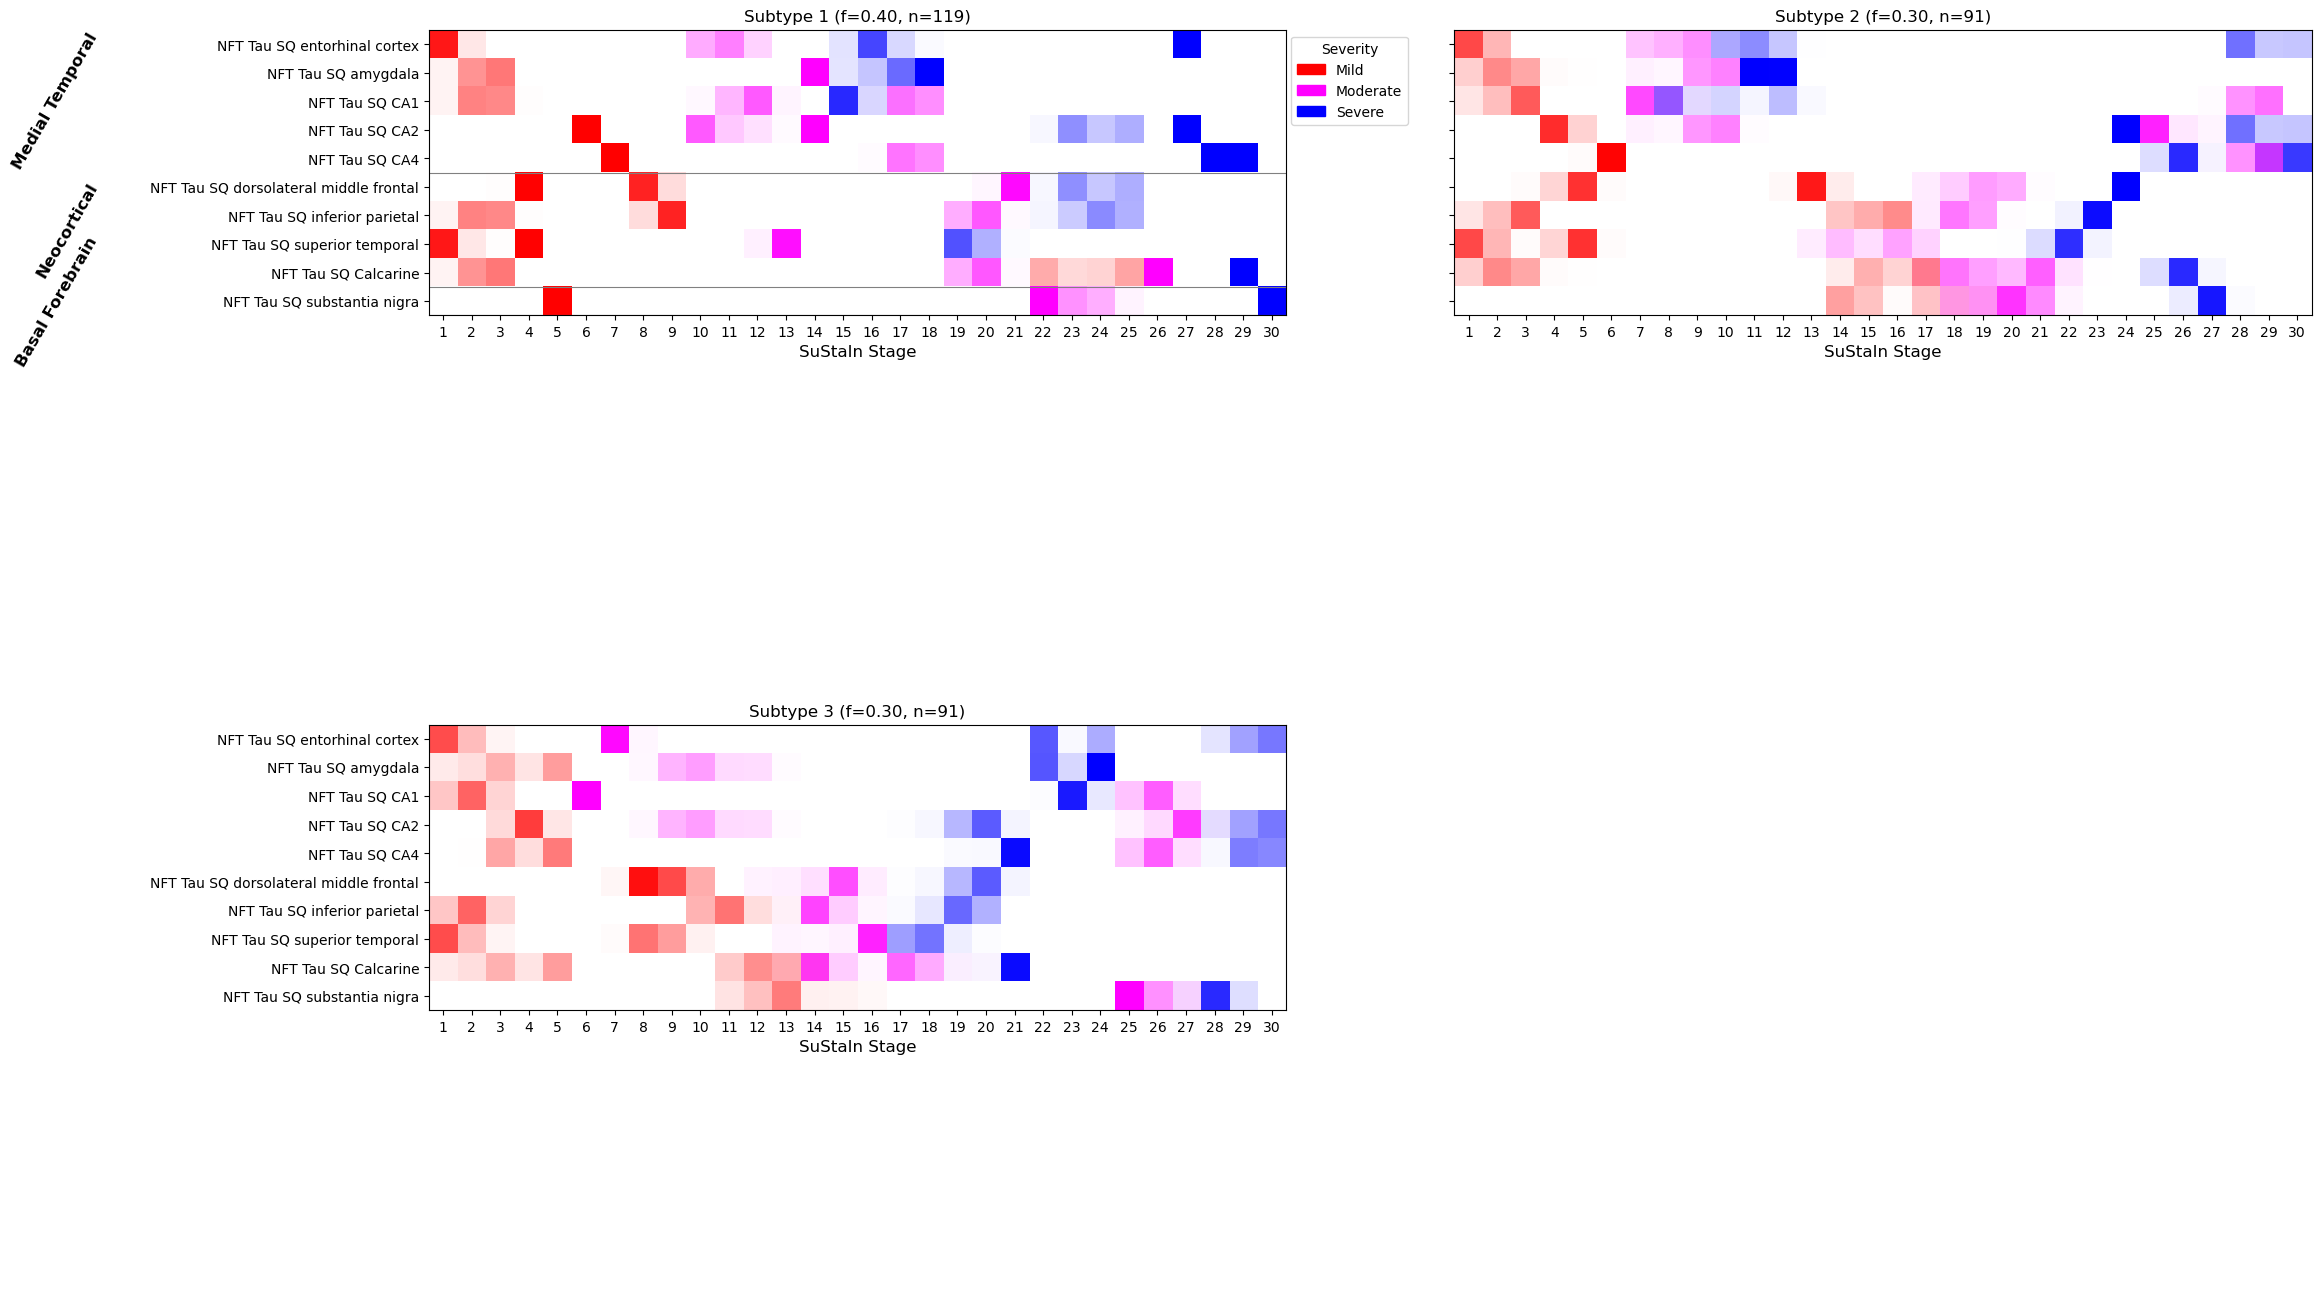

In [14]:
#plot again for HC grouping

#subtype order
subtype_order=[0,1,2]
#subtype_order=subtype_order[0:N_S_max] 

figs, ax = OrdinalSustain.plot_positional_var(
    samples_sequence=samples_sequence, #all of the predicted MCMC sequences across all biomarker severities and subtypes (n_subtypes, stages*severity levels, n_samples)
    samples_f=samples_f, # posterior probability ie likelihood that each mcmc summed sequence represents each subtype, given the data. This gives the shading
    n_samples=M, # number of mcmc samples (usually 10,000) can be more though
    score_vals=sustain_input.score_vals,       #The threshold values for severities
    biomarker_labels=biomarker_labels,         #The names of all the biomarkers aka brain regions we're looking at 
    subtype_order=subtype_order,                   #order of heatmaps to show based on subtype. Use a list [] not a tuple!
    figsize=(24, 16),                 # adjust for bigger figure
    biomarker_order = [8,9,5,6,7,0,1,2,3,4] #adjusted for braak + anatomical correctness and progression
)

#add legend if we want
legend_labels = ['Mild', 'Moderate', 'Severe']  # adjust if more levels
legend_colors = ['red', 'magenta', 'blue']  # match the order in colour_mat
#Create legend patches
patches = [Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Access the active axis (depends on SuStaIn version)
# If multiple subtypes, use: ax = figs[0].axes[0]
ax = figs[0].axes[0] if hasattr(figs[0], 'axes') else ax

# Define the groups and their index ranges (adjust if reordered)
group_labels = {
    "Neocortical": [5,6,7,8],
    "Medial Temporal": [0,1,2,3,4],
    "Basal Forebrain": [9]
}

# Add horizontal separators and group labels
for label, idxs in group_labels.items():
    y_center = np.mean(idxs)  # vertical midpoint for the group
    ax.text(
        -12, y_center, label, va='center', ha='right',
        fontsize=12, fontweight='bold', color='black', rotation=60,
        transform=ax.transData
    )
    # Add a faint horizontal line below the group
    ax.axhline(max(idxs)+0.5, color='gray', linewidth=0.8, alpha=1)

# Adjust axis limits if labels overlap
ax.set_ylim(len(biomarker_labels)-0.5, -0.5)

from matplotlib.patches import Patch

# Your legend info
legend_labels = ['Mild', 'Moderate', 'Severe']  
legend_colors = ['red', 'magenta', 'blue']  # match your colormap for severities

# Create legend patches
patches = [Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Access the main axis (depends on SuStaIn version)
ax = figs[0].axes[0] if hasattr(figs[0], 'axes') else ax

# Add legend to the axis
ax.legend(handles=patches, title="Severity", loc="upper right", bbox_to_anchor=(1.15, 1))

# Optional: adjust layout to prevent clipping
plt.tight_layout()

#optional to add a grid here:
'''
# Get dimensions from the plotted image
im = ax.images[0]
data = im.get_array()
n_rows, n_cols = 10,30

# Set minor ticks at cell boundaries (offset by 0.5)
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

# Draw grid on those minor ticks
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)

# Turn off major grid
ax.grid(False, which='major')
# Optional: adjust layout to prevent clipping
plt.tight_layout()
'''

#save this figure to the output folder::
filename = (
    f"PVD_HC_{os.path.basename(output_folder)}_"
    f"Likelihood{low_prob}_{high_prob}_"
    f"{N_S_max}_subtypes_{dataset_name}_.png"
)

save_path = os.path.join(output_folder, filename)

plt.savefig(save_path, dpi=300, bbox_inches="tight") #looks like by adjusting (increasing) this dpi you can increase the contrast level
plt.show()

## Additional Sustain Heatmap selective plotting

/Users/elihallowell/Documents/BU2024/Thesis/sustainrepo/pySuStaIn1/pySuStaIn/OrdinalSustain.py:476: UserWarning: Both labels and an order have been given. The labels will be reordered according to the given order!
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4214..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.01440000000000008..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21500000000000008..1.0].


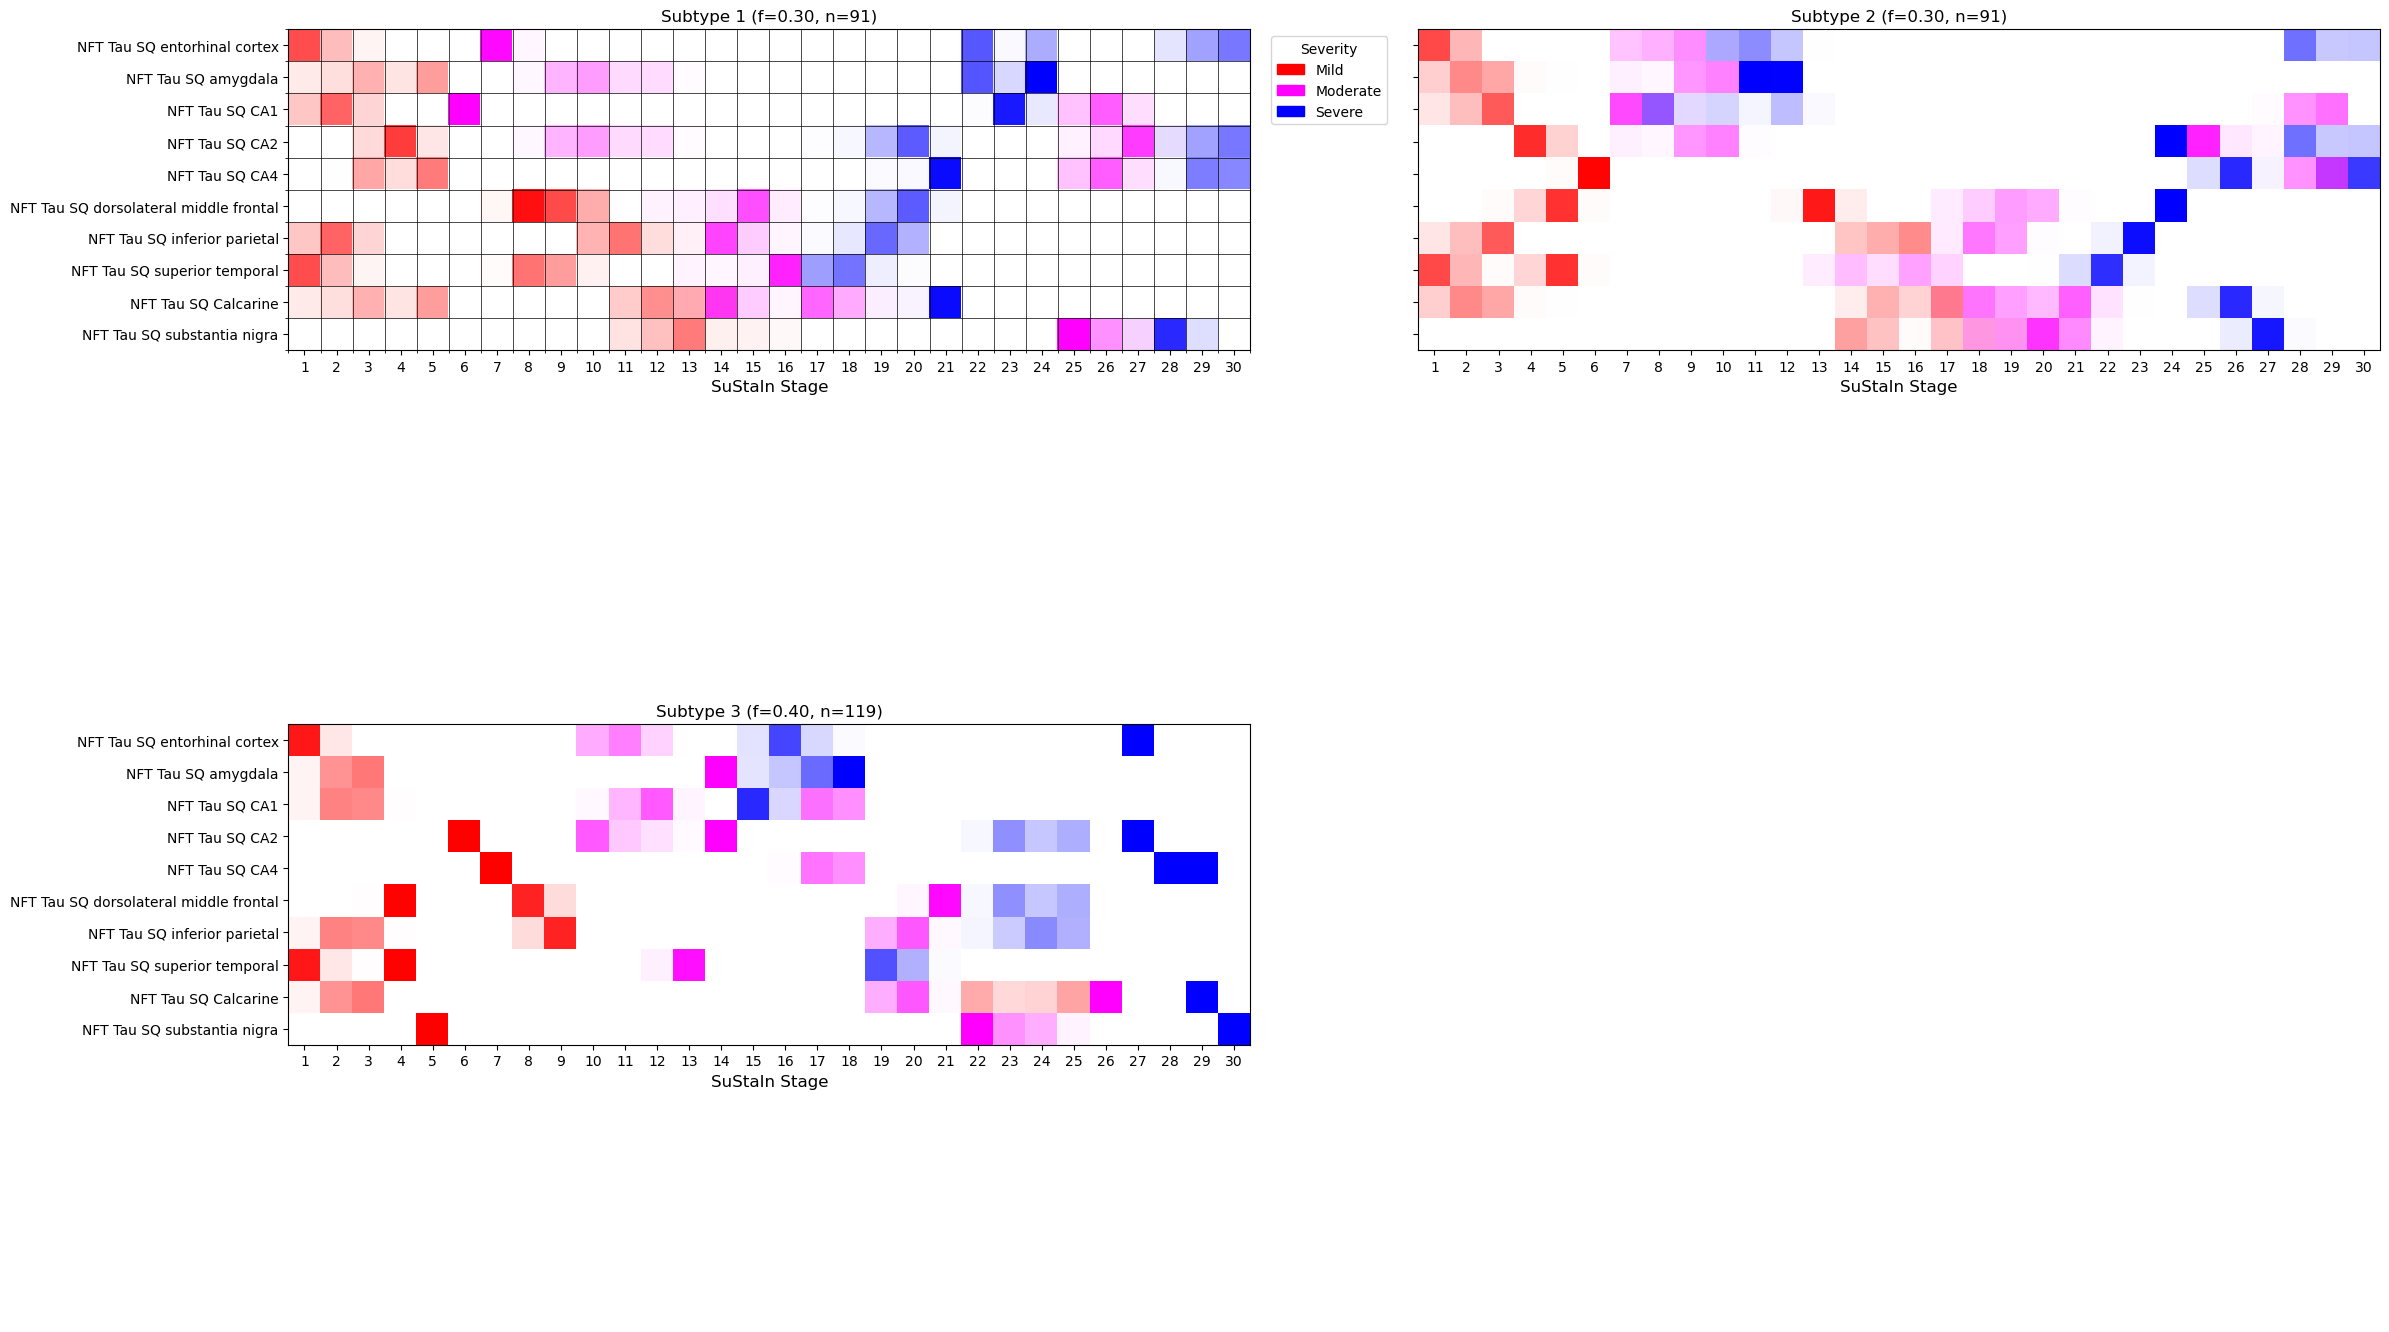

In [38]:
#plot again selective ST regional plotting
from matplotlib.patches import Patch

#subtype order
subtype_order=[2,1,0]
#subtype_order=subtype_order[0:N_S_max] 

#choose which biomarker to look at here
#single out specific biomarkers to extract here
bm = 8 # just looking at entorhinal here

figs, ax = OrdinalSustain.plot_positional_var(
    samples_sequence=samples_sequence, #all of the predicted MCMC sequences across all biomarker severities and subtypes (n_subtypes, stages*severity levels, n_samples)
    samples_f=samples_f, # posterior probability ie likelihood that each mcmc summed sequence represents each subtype, given the data. This gives the shading
    n_samples=M, # number of mcmc samples (usually 10,000) can be more though
    score_vals=sustain_input.score_vals,       #The threshold values for severities
    biomarker_labels=biomarker_labels,         #The names of all the biomarkers aka brain regions we're looking at 
    subtype_order=subtype_order,                   #order of heatmaps to show based on subtype. Use a list [] not a tuple!
    figsize=(24, 16),                 # adjust for bigger figure
    biomarker_order = [8,9,5,6,7,0,1,2,3,4]
)

#[8,9,5,6,7,0,1,2,3,4] # adjusted for braak + anatomical correctness and progression

#add legend if we want
legend_labels = ['Mild', 'Moderate', 'Severe']  # adjust if more levels
legend_colors = ['red', 'magenta', 'blue']  # match the order in colour_mat

#Create legend patches
patches = [Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Access the active axis (depends on SuStaIn version)
# If multiple subtypes, use: ax = figs[0].axes[0]
ax = figs[0].axes[0] if hasattr(figs[0], 'axes') else ax

# Adjust axis limits if labels overlap
ax.set_ylim(len(biomarker_labels)-0.5, -0.5)

# Your legend info
legend_labels = ['Mild', 'Moderate', 'Severe']  
legend_colors = ['red', 'magenta', 'blue']  # match your colormap for severities

# Create legend patches
patches = [Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Access the main axis (depends on SuStaIn version)
ax = figs[0].axes[0] if hasattr(figs[0], 'axes') else ax

# Add legend to the axis
ax.legend(handles=patches, title="Severity", loc="upper right", bbox_to_anchor=(1.15, 1))

#grid
# Get dimensions from the plotted image
im = ax.images[0]
data = im.get_array()
n_rows, n_cols = 10,30

# Set minor ticks at cell boundaries (offset by 0.5)
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

# Draw grid on those minor ticks
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)

# Turn off major grid
ax.grid(False, which='major')
# Optional: adjust layout to prevent clipping
plt.tight_layout()

#save this figure to the output folder::
filename = (
    f"PVD_single_{os.path.basename(output_folder)}_"
    f"{bm}_.png" #which biomarker we are looking at here
)

#dont save for now:::

#save_path = os.path.join(output_folder, filename)

#plt.savefig(save_path, dpi=300, bbox_inches="tight") #looks like by adjusting (increasing) this dpi you can increase the contrast level
#plt.show()

# Post SuStaIn Analysis: Preparation

### The results are stored in pickle files so these could be loaded, upacked, and analyzed in a separate script

### Use Sustain's built in function for assigning subtype and stage: 

In [56]:
print("stage_biomarker_index shape:", sustain_input.stage_biomarker_index.shape)
print("stage_score shape:", sustain_input.stage_score.shape)
print("prob_nl shape:", prob_nl.shape)
print("prob_score shape:", prob_score.shape)
print("Number of biomarkers used in new data:", prob_nl.shape[1])
print("Unique biomarker IDs:", np.unique(sustain_input.stage_biomarker_index))
print("Max biomarker index:", np.max(sustain_input.stage_biomarker_index))
print(sustain_input.stage_biomarker_index)

stage_biomarker_index shape: (1, 30)
stage_score shape: (1, 30)
prob_nl shape: (301, 10)
prob_score shape: (301, 10, 3)
Number of biomarkers used in new data: 10
Unique biomarker IDs: [0 1 2 3 4 5 6 7 8 9]
Max biomarker index: 9
[[0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9]]


In [57]:
#ISSUES if biomarker index is not (1 x 30) ...

#Assign the subjects to stage and subtype
# This is the built in sustain method for assigning subtype and stage back onto patients
n_samples = X.shape[0]

ml_subtype, prob_ml_subtype, ml_stage, prob_ml_stage, \
prob_subtype, prob_stage, prob_subtype_stage = sustain_input.subtype_and_stage_individuals_newData(
    prob_nl,        # P(normal) for each subject/biomarker
    prob_score,     # P(score | biomarker)
    samples_sequence,
    samples_f,
    n_samples
)

In [58]:
#make results_df with this data
#Define the ID column name that matches your dataset
id_col = "Case ID"  
#Make sure arrays are the same length as data
print(len(data[id_col]), len(ml_subtype))  # sanity check

# Flatten 2D arrays> 1D
ml_subtype = ml_subtype.ravel()
ml_stage = ml_stage.ravel()
prob_ml_subtype = prob_ml_subtype.ravel()
prob_ml_stage = prob_ml_stage.ravel()

# Merge SuStaIn results into a new DataFrame
results_df = pd.DataFrame({
    id_col: data[id_col],
    'SuStaIn_subtype': ml_subtype,
    'SuStaIn_stage': ml_stage,
    'SuStaIn_subtype_prob': prob_ml_subtype,
    'SuStaIn_stage_prob': prob_ml_stage
})

# Display preview
display(results_df.head())

301 301


,Case ID,SuStaIn_subtype,SuStaIn_stage,SuStaIn_subtype_prob,SuStaIn_stage_prob
0,BVAX029,1.0,23.0,0.996980,0.892214
1,BVAX056,1.0,13.0,0.994652,0.832174
2,BVAX057,0.0,19.0,0.737136,0.254119
3,BVAX060,1.0,5.0,0.845862,0.774825
4,BVAX062,1.0,22.0,0.369519,0.314291


### Merge the Sustain Stage and Subtype assignment with the full data sheet

In [59]:
# Merge by row, matching case ID in both datasets: it should create a dataset called 'full_data_with_sustain
# Load the full dataset
data_fs = pd.read_csv('/Users/elihallowell/Documents/BU2024/Thesis/Data/AD SuStaIn data_ABCscore_fullsheet.csv')

# Define the ID column used in both datasets
id_col = "Case ID"   # update this if your identifier has a slightly different name

# Check that both DataFrames contain the column
print("Columns in results_df:", results_df.columns)
print("Columns in data_fs:", data_fs.columns)

# Ensure consistent column naming (strip whitespace, etc.)
results_df.columns = results_df.columns.str.strip()
data_fs.columns = data_fs.columns.str.strip()

# Merge the two datasets
full_data_with_sustain = pd.merge(
    data_fs,
    results_df,
    how='left',       # keep all rows from data_fs, add SuStaIn results where available
    on=id_col
)

Columns in results_df: Index(['Case ID', 'SuStaIn_subtype', 'SuStaIn_stage', 'SuStaIn_subtype_prob',
       'SuStaIn_stage_prob'],
      dtype='object')
Columns in data_fs: Index(['Case ID', 'Cohort', 'RHI Exposure', 'Pathologic Group',
       'Donor age at death', ' gender',
       'Thal phase for amyloid plaques by IHC (A score)',
       'Braak stage for neurofibrillary degeneration (B score)',
       'CERAD score for density of neocortical neuritic plaques (C score)',
       'NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)',
       ...
       'SN', 'Caduate', 'Nucleus Accumbens', 'Putamen', 'CAP combined',
       'Substantia Innominata', 'Globus Pallidus', 'Mammillary body',
       'Thalamus', 'Cerebellum'],
      dtype='object', length=159)


## Take a look at the full data with staging and subtyping

In [60]:
# Display and confirm merge worked
print(f"Merged dataset shape: {full_data_with_sustain.shape}")
display(full_data_with_sustain.head(2))

#also look at the number of patients in each subtype in a table below
subtype_counts = (
    full_data_with_sustain['SuStaIn_subtype']
    .value_counts(dropna=False)
    .reset_index()
)

subtype_counts.columns = ['SuStaIn Subtype', 'Number of Patients']

display(results_df["SuStaIn_stage"].value_counts())

display(subtype_counts)

Merged dataset shape: (737, 163)


,Case ID,Cohort,RHI Exposure,Pathologic Group,Donor age at death,gender,Thal phase for amyloid plaques by IHC (A score),Braak stage for neurofibrillary degeneration (B score),CERAD score for density of neocortical neuritic plaques (C score),NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score),...,CAP combined,Substantia Innominata,Globus Pallidus,Mammillary body,Thalamus,Cerebellum,SuStaIn_subtype,SuStaIn_stage,SuStaIn_subtype_prob,SuStaIn_stage_prob
0,A0001,BU ADC,No,NaN,66,Male,NaN,6 Stage VI (B3),2 Moderate neuritic plaques (C2),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A0005,BU ADC,No,NaN,88,Male,NaN,5 Stage V (B3),3 Frequent neuritic plaques (C3),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


SuStaIn_stage
27.0    22
5.0     21
24.0    15
21.0    15
25.0    13
28.0    13
4.0     13
13.0    12
7.0     12
29.0    12
6.0     11
9.0     11
2.0     10
8.0     10
23.0     9
3.0      9
16.0     8
18.0     8
10.0     8
12.0     8
0.0      8
20.0     7
26.0     7
22.0     7
15.0     6
14.0     6
19.0     5
1.0      5
11.0     4
17.0     4
30.0     2
Name: count, dtype: int64

,SuStaIn Subtype,Number of Patients
0,NaN,436
1,0.0,140
2,1.0,82
3,2.0,79


### Optional: Check which cases are not control + Not AD 

In [61]:
# Check which cases are not control + Not AD and count them 
#store the list of cases by Case_ID 
#This can then be used in the next analysis

# Filter cleaned dataset for patients who are NOT controls AND have NIA-Reagan Score = "Not AD"
noncontrol_notAD_cleaned = full_data_with_sustain[
    (full_data_with_sustain["Pathologic Group"].astype(str).str.strip().str.lower() != "control") &
    (full_data_with_sustain["NIA-Reagan Score"].astype(str).str.strip().str.lower() == "not ad")
]

# Keep only the Case_ID column
noncontrol_notAD_caseIDs = noncontrol_notAD_cleaned[["Case ID"]].copy()

# Optional: reset index
noncontrol_notAD_caseIDs.reset_index(drop=True, inplace=True)

# Display results
print(f"Number of non-control patients with NIA-Reagan Score = 'Not AD': {noncontrol_notAD_caseIDs.shape[0]}")
display(noncontrol_notAD_caseIDs)

csv_path = os.path.join(output_folder, "noncontrol_notAD_caseIDs.csv")

# Save to CSV
noncontrol_notAD_caseIDs.to_csv(csv_path, index=False)

Number of non-control patients with NIA-Reagan Score = 'Not AD': 187


,Case ID
0,A0252
1,A0902
2,A9611
3,A9615
4,A9618
...,...
182,K1648
183,SLI100
184,SLI111
185,SLI114


## Clean the full data set to prepare it for analysis

In [62]:
# clean the full data set
import re
#define cleaning functio
def extract_if_mixed(cell):
    cell_str = str(cell)
    has_digit = bool(re.search(r'\d', cell_str))
    has_letter = bool(re.search(r'[a-zA-Z]', cell_str))
    
    if has_digit and has_letter:  # mixed case, extract numeric part
        match = re.search(r'-?\d+\.?\d*', cell_str)
        return float(match.group(0)) if match else np.nan
    else:
        return cell  # leave unchanged (numbers, NaN, or pure strings)

#Step 1: Remove rows without assigned subtype or stage
full_data_with_sustain_cleaned = full_data_with_sustain.dropna(
    subset=['SuStaIn_subtype', 'SuStaIn_stage']
).copy()  # copy to avoid SettingWithCopy warnings

print(f"Rows after filtering missing SuStaIn results: {full_data_with_sustain_cleaned.shape[0]}")

#Step 2: Apply the numeric extraction cleaning function to all columns
#full_data_with_sustain_cleaned = full_data_with_sustain_cleaned.applymap(extract_if_mixed)

# -------------------------------
# Drop rows where ABC_score is blank or missing
# -------------------------------
# full_data_with_sustain_cleaned= full_data_with_sustain_cleaned[full_data_with_sustain_cleaned["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"].notna() & (df_filtered["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"] != "")]

display(full_data_with_sustain_cleaned.head())
display(full_data_with_sustain_cleaned.shape)
print("Finished cleaning and filtering the dataset.")

Rows after filtering missing SuStaIn results: 301


,Case ID,Cohort,RHI Exposure,Pathologic Group,Donor age at death,gender,Thal phase for amyloid plaques by IHC (A score),Braak stage for neurofibrillary degeneration (B score),CERAD score for density of neocortical neuritic plaques (C score),NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score),...,CAP combined,Substantia Innominata,Globus Pallidus,Mammillary body,Thalamus,Cerebellum,SuStaIn_subtype,SuStaIn_stage,SuStaIn_subtype_prob,SuStaIn_stage_prob
172,BVAX029,FHS,No,NaN,82,Male,5 Thal Stage 5 (A3),5 Stage V (B3),1 Sparse neuritic plaques (C1),2 Intermediate ADNC,...,NaN,9.655409,0.191904,NaN,NaN,NaN,1.0,23.0,0.996980,0.892214
181,BVAX056,FHS,No,NaN,89,Female,4 Thal Stage 4 (A3),3 Stage III (B2),1 Sparse neuritic plaques (C1),2 Intermediate ADNC,...,NaN,6.276529,0.000000,3.539249838,0.499064,NaN,1.0,13.0,0.994652,0.832174
182,BVAX057,FHS,No,NaN,95,Female,5 Thal Stage 5 (A3),4 Stage IV (B2),1 Sparse neuritic plaques (C1),2 Intermediate ADNC,...,NaN,NaN,0.299896,0.333524888,0.000000,NaN,0.0,19.0,0.737136,0.254119
183,BVAX060,FHS,No,NaN,68,Female,3 Thal Stage 3 (A2),1 Stage I (B1),1 Sparse neuritic plaques (C1),1 Low ADNC,...,NaN,2.865640,0.000000,NaN,0.053608,NaN,1.0,5.0,0.845862,0.774825
184,BVAX062,FHS,No,NaN,93,Female,4 Thal Stage 4 (A3),4 Stage IV (B2),1 Sparse neuritic plaques (C1),2 Intermediate ADNC,...,NaN,23.820071,0.356417,NaN,NaN,NaN,1.0,22.0,0.369519,0.314291


(301, 163)

Finished cleaning and filtering the dataset.


# SAVE the Full sustain output data 

In [63]:
# SAVE filtered data!!!!!
# -------------------------------
folder_name = os.path.basename(output_folder)
filename = f"filtered_full_data_with_sustain_ABC_{folder_name}.csv"
save_path = os.path.join(output_folder, filename)
full_data_with_sustain_cleaned.to_csv(save_path, index=False)

# Everything below is just analysis that can be done in the separate analysis notebook

### Add in extra ABC scores

In [51]:
'''
# Load the new ABC CSV
abc_csv_path = "/Users/elihallowell/Documents/BU2024/Thesis/AD SuStaIn data_ABCscore.csv"
abc_df = pd.read_csv(abc_csv_path)

# Keep only the ID and ABC score column
long_name = "NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"
abc_df = abc_df[["Case ID", long_name]].rename(columns={long_name: "ABC_score"})

# Strip whitespace and ensure type consistency
full_data_with_sustain["Case ID"] = full_data_with_sustain["Case ID"].astype(str).str.strip()
abc_df["Case ID"] = abc_df["Case ID"].astype(str).str.strip()

# Merge with the existing full_data_with_sustain
full_data_with_sustain = pd.merge(
    full_data_with_sustain,
    abc_df,
    how='left',        # keeps all rows from full_data_with_sustain
    on="Case ID"
)

# Check the merge
print("Subjects with ABC_score:", full_data_with_sustain["ABC_score"].notna().sum())
display(full_data_with_sustain[["Case ID", "ABC_score"]].head())
'''

'\n# Load the new ABC CSV\nabc_csv_path = "/Users/elihallowell/Documents/BU2024/Thesis/AD SuStaIn data_ABCscore.csv"\nabc_df = pd.read_csv(abc_csv_path)\n\n# Keep only the ID and ABC score column\nlong_name = "NIA-AA Alzheimer\'s disease neuropathologic change (ADNC) (ABC score)"\nabc_df = abc_df[["Case ID", long_name]].rename(columns={long_name: "ABC_score"})\n\n# Strip whitespace and ensure type consistency\nfull_data_with_sustain["Case ID"] = full_data_with_sustain["Case ID"].astype(str).str.strip()\nabc_df["Case ID"] = abc_df["Case ID"].astype(str).str.strip()\n\n# Merge with the existing full_data_with_sustain\nfull_data_with_sustain = pd.merge(\n    full_data_with_sustain,\n    abc_df,\n    how=\'left\',        # keeps all rows from full_data_with_sustain\n    on="Case ID"\n)\n\n# Check the merge\nprint("Subjects with ABC_score:", full_data_with_sustain["ABC_score"].notna().sum())\ndisplay(full_data_with_sustain[["Case ID", "ABC_score"]].head())\n'

# Post SuStaIn Analysis: Visualization

## Stage distribution by subtype

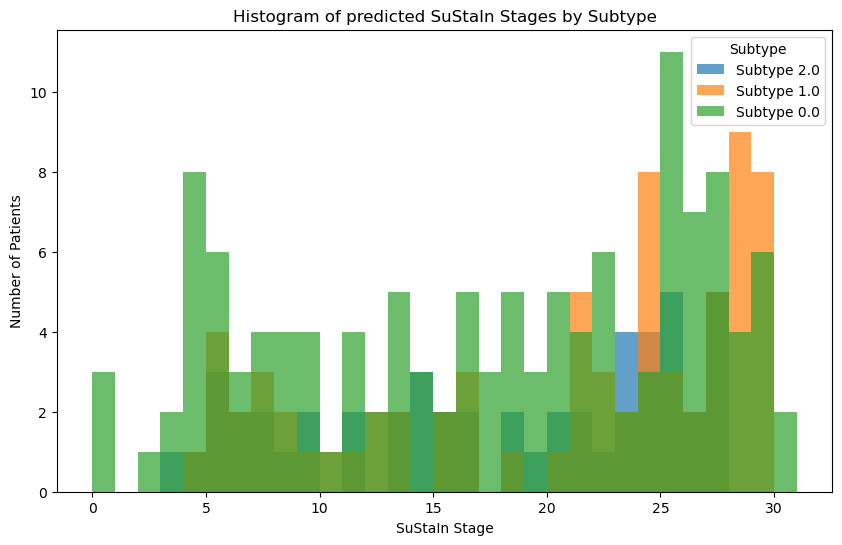

In [52]:
import matplotlib.pyplot as plt

# Unique subtypes
subtypes = results_df["SuStaIn_subtype"].unique()
colors = plt.cm.tab10.colors  # up to 10 colors

plt.figure(figsize=(10, 6))

# Determine stage range
min_stage = int(results_df["SuStaIn_stage"].min())
max_stage = int(results_df["SuStaIn_stage"].max())
bins = range(min_stage, max_stage + 2)  # +2 to include the last stage

# Loop through subtypes and plot each histogram
for i, s in enumerate(subtypes):
    subset = results_df[results_df["SuStaIn_subtype"] == s]
    plt.hist(
        subset["SuStaIn_stage"].astype(int),
        bins=bins,
        alpha=0.7,
        label=f"Subtype {s}",
        color=colors[i % len(colors)]
    )

plt.xlabel("SuStaIn Stage")
plt.ylabel("Number of Patients")
plt.title("Histogram of predicted SuStaIn Stages by Subtype")
plt.legend(title="Subtype")

# Save the figure
folder_name = os.path.basename(output_folder)

filename = f"sustain_stage_histogram_{folder_name}.png"
save_path = os.path.join(output_folder, filename)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

## Correlations between staging/subtyping and other variables 

### Braak stage correlation to sustain stage

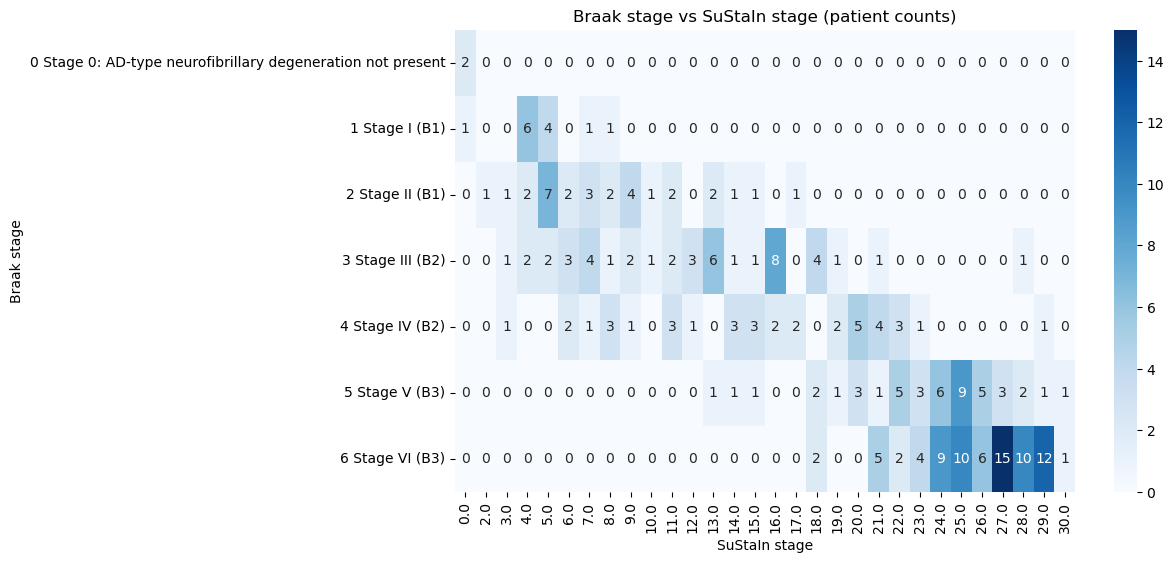

In [53]:
# create a heatmap that shows the braak stage category on the y axis and sustian stage on the x axis for all the patients
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Braak_stage is categorical
full_data_with_sustain["Braak stage for neurofibrillary degeneration (B score)"] = full_data_with_sustain["Braak stage for neurofibrillary degeneration (B score)"].astype(str)

# Create a cross-tab of counts
count_table = pd.crosstab(
    full_data_with_sustain["Braak stage for neurofibrillary degeneration (B score)"],
    full_data_with_sustain["SuStaIn_stage"]
)

# Plot as a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(count_table, annot=True, fmt="d", cmap="Blues")
plt.xlabel("SuStaIn stage")
plt.ylabel("Braak stage")
plt.title("Braak stage vs SuStaIn stage (patient counts)")

# Save the figure
folder_name = os.path.basename(output_folder)

filename = f"Sustain_stage_v_Braak_{folder_name}.png"
save_path = os.path.join(output_folder, filename)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

### Reagan score correlation with Subtype

### ABC score correlation with stage

In [ ]:
# -------------------------------
# Cross-tab of counts
# -------------------------------
count_table = pd.crosstab(
    df_filtered["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"],
    df_filtered["SuStaIn_stage"]
).sort_index(axis=0).sort_index(axis=1)

# -------------------------------
# Plot heatmap
# -------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(count_table, annot=True, fmt="d", cmap="Purples")
plt.xlabel("SuStaIn Stage")
plt.ylabel("ABC Score")
plt.title("Breakdown of SuStaIn Subtypes by ABC Score (patient counts)")
plt.gca().invert_yaxis()

# Save figure
filename = f"Sustain_subtype_v_ABC_filtered_{folder_name}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### Reagan score correlation with Stage

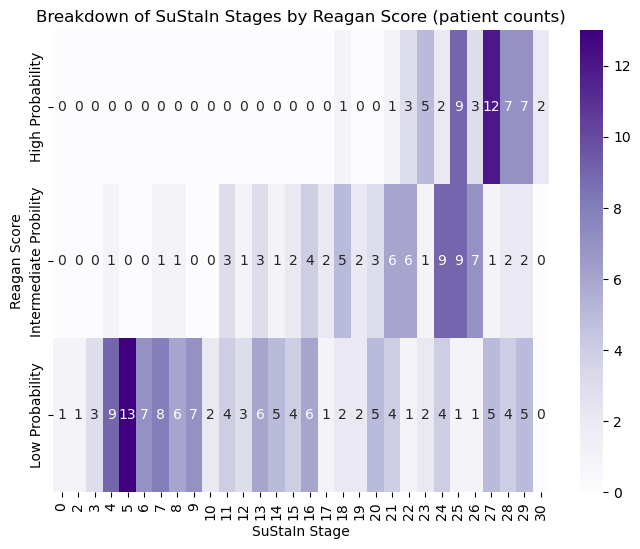

In [57]:
# Make a copy to avoid modifying the original
df_filtered = full_data_with_sustain.copy()

df_filtered = full_data_with_sustain.dropna(subset=["SuStaIn_subtype", "SuStaIn_stage"]).copy()

# Drop rows where ml_stage is actual NaN
df_filtered = df_filtered[df_filtered["SuStaIn_stage"].notna()]

# Drop rows where ml_stage is the string 'nan'
df_filtered = df_filtered[df_filtered["SuStaIn_stage"] != 'nan']

#drop the blanks
# Drop rows where Reagan score is blank or missing
df_filtered = df_filtered[df_filtered["NIA-Reagan Score"].notna() & (df_filtered["NIA-Reagan Score"] != "")]

# Now convert remaining values to float, then int
df_filtered["SuStaIn_stage"] = df_filtered["SuStaIn_stage"].astype(float).astype(int)

# Convert Reagan score to string for categorical plotting
df_filtered["NIA-Reagan Score"] = df_filtered["NIA-Reagan Score"].astype(str)

# Cross-tab of counts
count_table = pd.crosstab(
    df_filtered["NIA-Reagan Score"],
    df_filtered["SuStaIn_stage"]
)

# Order the stages numerically
ordered_stages = sorted(count_table.columns)
count_table = count_table[ordered_stages]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(count_table, annot=True, fmt="d", cmap="Purples")
plt.xlabel("SuStaIn Stage")
plt.ylabel("Reagan Score")
plt.title("Breakdown of SuStaIn Stages by Reagan Score (patient counts)")


#save the figure
folder_name = os.path.basename(output_folder)

filename = f"Sustain_stage_v_Reagan_filtered_{folder_name}.png"
save_path = os.path.join(output_folder, filename)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

### Reagan score correlation with stage by stubype

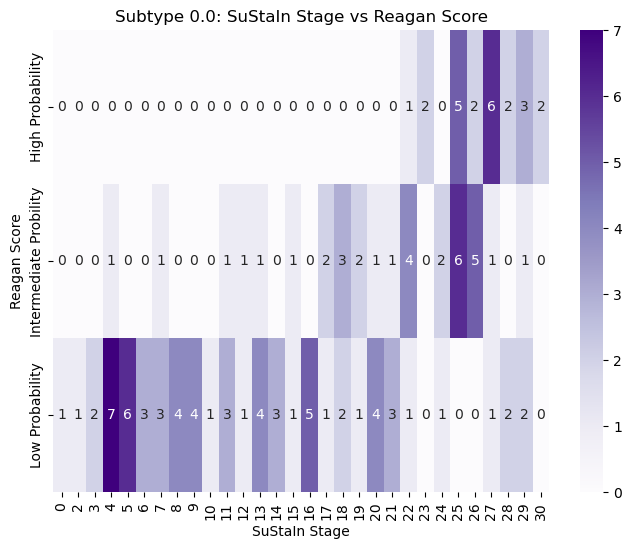

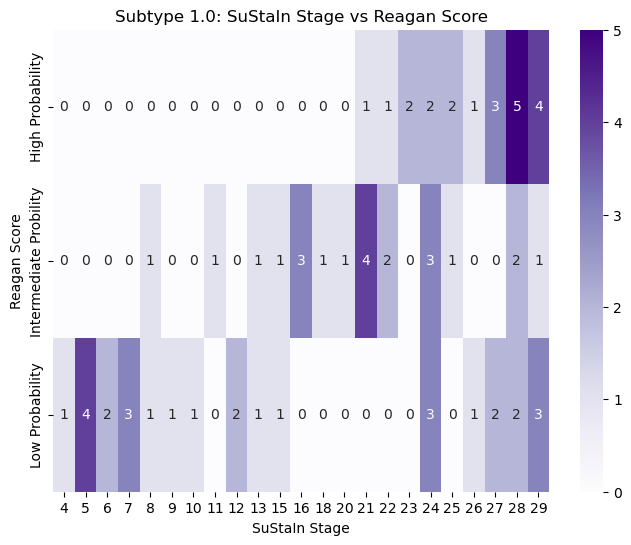

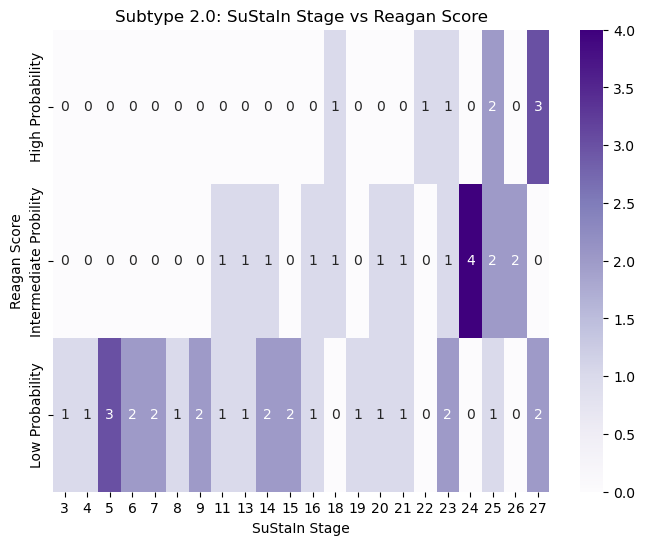

In [60]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Filter data ONCE
# -------------------------------

df_filtered = full_data_with_sustain.dropna(
    subset=["SuStaIn_subtype", "SuStaIn_stage"]
).copy()

# Drop blank / missing Reagan scores
df_filtered = df_filtered[
    df_filtered["NIA-Reagan Score"].notna() &
    (df_filtered["NIA-Reagan Score"] != "")
]

# Convert stage to int
df_filtered["SuStaIn_stage"] = (
    df_filtered["SuStaIn_stage"].astype(float).astype(int)
)

# Reagan score as categorical
df_filtered["NIA-Reagan Score"] = df_filtered["NIA-Reagan Score"].astype(str)

# -------------------------------
# Loop over subtypes
# -------------------------------
subtypes = sorted(df_filtered["SuStaIn_subtype"].unique())

for subtype in subtypes:

    subtype_df = df_filtered[df_filtered["SuStaIn_subtype"] == subtype]

    # Cross-tab
    count_table = pd.crosstab(
        subtype_df["NIA-Reagan Score"],
        subtype_df["SuStaIn_stage"]
    )

    # Ensure stage order
    count_table = count_table[sorted(count_table.columns)]

    # -------------------------------
    # Plot heatmap
    # -------------------------------
    plt.figure(figsize=(8, 6))
    sns.heatmap(count_table, annot=True, fmt="d", cmap="Purples")

    plt.xlabel("SuStaIn Stage")
    plt.ylabel("Reagan Score")
    plt.title(f"Subtype {subtype}: SuStaIn Stage vs Reagan Score")

    # Save figure
    folder_name = os.path.basename(output_folder)
    filename = f"Sustain_stage_v_Reagan_subtype_{subtype}_{folder_name}.png"
    save_path = os.path.join(output_folder, filename)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
df = df_filtered # to keep consistency for below

### Regression: stage v regan score v subtype 

In [62]:
# Make sure stage is numeric
df["SuStaIn_stage"] = pd.to_numeric(df["SuStaIn_stage"], errors="coerce")
df = df.dropna(subset=["SuStaIn_stage"])  # drop rows that couldn't convert

# Strip whitespace from subtype
df["SuStaIn_subtype"] = df["SuStaIn_subtype"].astype(str).str.strip()

# Create dummy variables for subtype
X = pd.get_dummies(df[["SuStaIn_stage", "SuStaIn_subtype"]], drop_first=True)

# Ensure all columns are float
X = X.astype(float)


reagan_map = {
    "Low Probability": 1,
    "Intermediate Probility": 2,
    "High Probability": 3
}
df["Reagan_numeric"] = df["NIA-Reagan Score"].map(reagan_map)

# Drop any rows where mapping failed
df = df.dropna(subset=["Reagan_numeric"])
y = df["Reagan_numeric"].astype(float)



from statsmodels.miscmodels.ordinal_model import OrderedModel

mod = OrderedModel(
    y,
    X,
    distr="logit"
)

res = mod.fit(method="bfgs", disp=False)
print(res.summary())


                             OrderedModel Results                             
Dep. Variable:         Reagan_numeric   Log-Likelihood:                -192.83
Model:                   OrderedModel   AIC:                             395.7
Method:            Maximum Likelihood   BIC:                             413.2
Date:                Wed, 28 Jan 2026                                         
Time:                        20:48:14                                         
No. Observations:                 246                                         
Df Residuals:                     241                                         
Df Model:                           3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
SuStaIn_stage           0.2077      0.023      8.869      0.000       0.162       0.254
SuStaIn_subtype_1.0     0

### ABC score versus Reagan score across all subjects

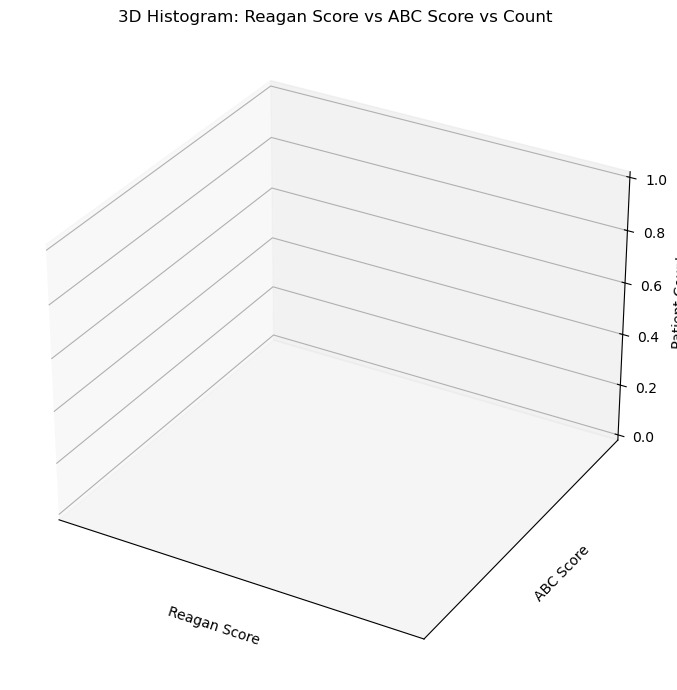

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# -------------------------------
# Prepare data
# -------------------------------
df_corr = df.dropna(subset=[
    "NIA-Reagan Score", 
    "NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"
]).copy()

# Clean Reagan score
df_corr["NIA-Reagan Score"] = df_corr["NIA-Reagan Score"].astype(str).str.strip()

# Ensure ABC score is numeric
df_corr["ABC_score"] = pd.to_numeric(
    df_corr["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"],
    errors='coerce'
)
df_corr = df_corr.dropna(subset=["ABC_score"])

# -------------------------------
# Create 2D counts table
# -------------------------------
count_table = pd.crosstab(df_corr["NIA-Reagan Score"], df_corr["ABC_score"])

# X: Reagan score categories
x_labels = count_table.index.tolist()
x_pos = np.arange(len(x_labels))

# Y: ABC score categories
y_labels = count_table.columns.tolist()
y_pos = np.arange(len(y_labels))

# Z: counts
X, Y = np.meshgrid(x_pos, y_pos, indexing='ij')
Z = count_table.values

# -------------------------------
# 3D bar plot
# -------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

dx = dy = 0.5  # width of bars
dz_scale = 1   # scale of counts

for i in range(len(x_pos)):
    for j in range(len(y_pos)):
        ax.bar3d(
            x=X[i, j],
            y=Y[i, j],
            z=0,
            dx=dx,
            dy=dy,
            dz=Z[i, j]*dz_scale,
            color='mediumpurple',
            alpha=0.8
        )

# Axes labels
ax.set_xticks(x_pos + dx/2)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Reagan Score")

ax.set_yticks(y_pos + dy/2)
ax.set_yticklabels(y_labels)
ax.set_ylabel("ABC Score")

ax.set_zlabel("Patient Count")
ax.set_title("3D Histogram: Reagan Score vs ABC Score vs Count")

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


/var/folders/yq/blfjj9vn7vvf5tt08v98q_qr0000gn/T/ipykernel_66222/1641134073.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reagan["NIA-Reagan Score"] = df_reagan["NIA-Reagan Score"].str.strip()


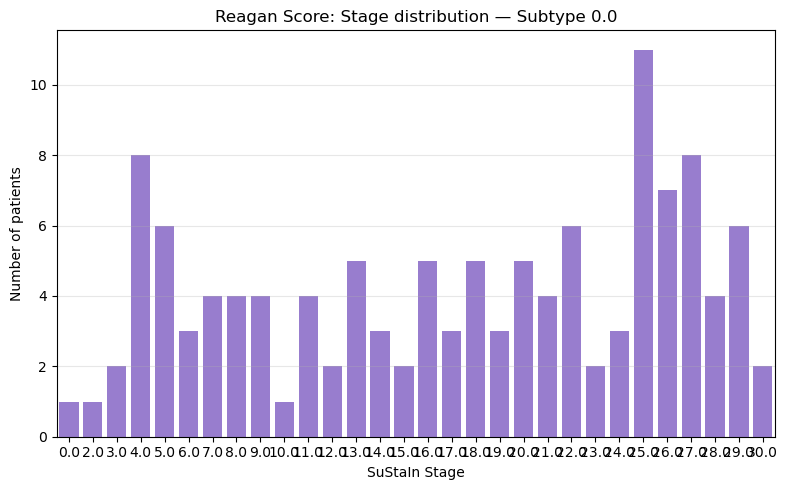

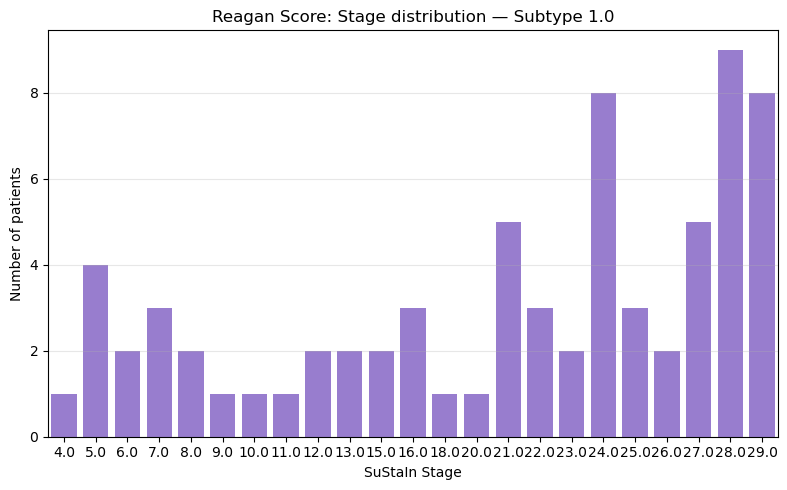

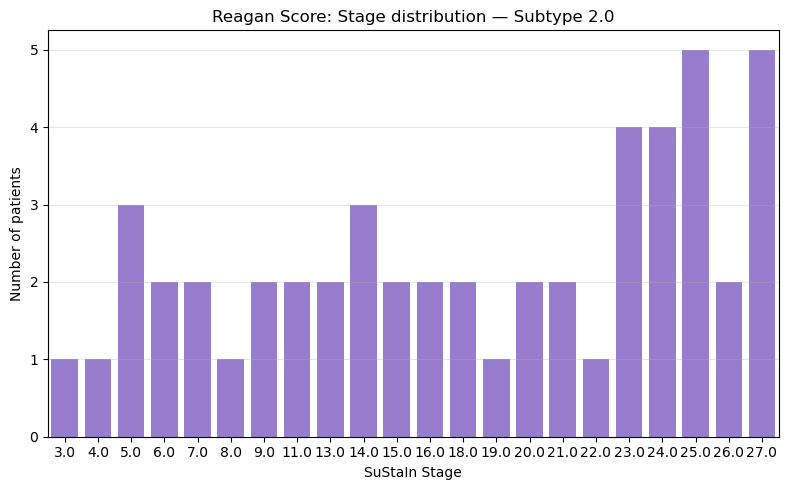

Chi-squared test (Reagan):
Chi2 = 5.881141917870369 , p-value = 0.20820224651350397 , dof = 4

Ordinal regression: Reagan ~ stage + subtype
                             OrderedModel Results                             
Dep. Variable:         Reagan_numeric   Log-Likelihood:                -57.868
Model:                   OrderedModel   AIC:                             123.7
Method:            Maximum Likelihood   BIC:                             136.4
Date:                Wed, 28 Jan 2026                                         
Time:                        20:48:15                                         
No. Observations:                 174                                         
Df Residuals:                     170                                         
Df Model:                           3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

/var/folders/yq/blfjj9vn7vvf5tt08v98q_qr0000gn/T/ipykernel_66222/1641134073.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reagan["Reagan_numeric"] = df_reagan["NIA-Reagan Score"].map(reagan_map)


AttributeError: Can only use .str accessor with string values!

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import chi2_contingency

# ----------------------------------
# 1️⃣ Clean dataframe
# ----------------------------------
df = full_data_with_sustain_cleaned.copy()

# Keep rows with valid SuStaIn outputs
df = df.dropna(subset=["SuStaIn_subtype", "SuStaIn_stage"])

# Ensure stage is numeric
df["SuStaIn_stage"] = pd.to_numeric(df["SuStaIn_stage"], errors="coerce")
df = df.dropna(subset=["SuStaIn_stage"])

# Strip whitespace from subtype
df["SuStaIn_subtype"] = df["SuStaIn_subtype"].astype(str).str.strip()

# -------------------------------
# 2️⃣ Reagan Score Analysis
# -------------------------------
df_reagan = df[df["NIA-Reagan Score"].notna() & (df["NIA-Reagan Score"] != "")]
df_reagan["NIA-Reagan Score"] = df_reagan["NIA-Reagan Score"].str.strip()

# Plot: histogram per subtype
subtypes = sorted(df_reagan["SuStaIn_subtype"].unique())
for subtype in subtypes:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=df_reagan[df_reagan["SuStaIn_subtype"] == subtype],
        x="SuStaIn_stage",
        color="mediumpurple"
    )
    plt.xlabel("SuStaIn Stage")
    plt.ylabel("Number of patients")
    plt.title(f"Reagan Score: Stage distribution — Subtype {subtype}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Chi-squared test: subtype vs Reagan
cont_table = pd.crosstab(df_reagan["SuStaIn_subtype"], df_reagan["NIA-Reagan Score"])
chi2, p, dof, expected = chi2_contingency(cont_table)
print("Chi-squared test (Reagan):")
print("Chi2 =", chi2, ", p-value =", p, ", dof =", dof)

# Ordinal regression: Reagan ~ stage + subtype
reagan_map = {
    "Low Probability": 1,
    "Intermediate Probability": 2,
    "High Probability": 3
}
df_reagan["Reagan_numeric"] = df_reagan["NIA-Reagan Score"].map(reagan_map)
df_reagan = df_reagan.dropna(subset=["Reagan_numeric"])
y = df_reagan["Reagan_numeric"].astype(float)
X = pd.get_dummies(df_reagan[["SuStaIn_stage","SuStaIn_subtype"]], drop_first=True).astype(float)

mod = OrderedModel(y, X, distr="logit")
res = mod.fit(method="bfgs", disp=False)
print("\nOrdinal regression: Reagan ~ stage + subtype")
print(res.summary())

# -------------------------------
# 3️⃣ ABC Score Analysis
# -------------------------------
df_abc = df[df["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"].notna() &
            (df["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"] != "")]
df_abc["ABC_score"] = df_abc["NIA-AA Alzheimer's disease neuropathologic change (ADNC) (ABC score)"].str.strip()

# Plot: histogram per subtype
for subtype in sorted(df_abc["SuStaIn_subtype"].unique()):
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=df_abc[df_abc["SuStaIn_subtype"] == subtype],
        x="SuStaIn_stage",
        color="skyblue"
    )
    plt.xlabel("SuStaIn Stage")
    plt.ylabel("Number of patients")
    plt.title(f"ABC Score: Stage distribution — Subtype {subtype}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Chi-squared test: subtype vs ABC
cont_table_abc = pd.crosstab(df_abc["SuStaIn_subtype"], df_abc["ABC_score"])
chi2_abc, p_abc, dof_abc, expected_abc = chi2_contingency(cont_table_abc)
print("Chi-squared test (ABC):")
print("Chi2 =", chi2_abc, ", p-value =", p_abc, ", dof =", dof_abc)

# Ordinal regression: ABC ~ stage + subtype
abc_map = {"A": 1, "B": 2, "C": 3}  # adjust mapping to your actual labels
df_abc["ABC_numeric"] = df_abc["ABC_score"].map(abc_map)
df_abc = df_abc.dropna(subset=["ABC_numeric"])
y_abc = df_abc["ABC_numeric"].astype(float)
X_abc = pd.get_dummies(df_abc[["SuStaIn_stage","SuStaIn_subtype"]], drop_first=True).astype(float)

mod_abc = OrderedModel(y_abc, X_abc, distr="logit")
res_abc = mod_abc.fit(method="bfgs", disp=False)
print("\nOrdinal regression: ABC ~ stage + subtype")
print(res_abc.summary())


### Check where control patients fall

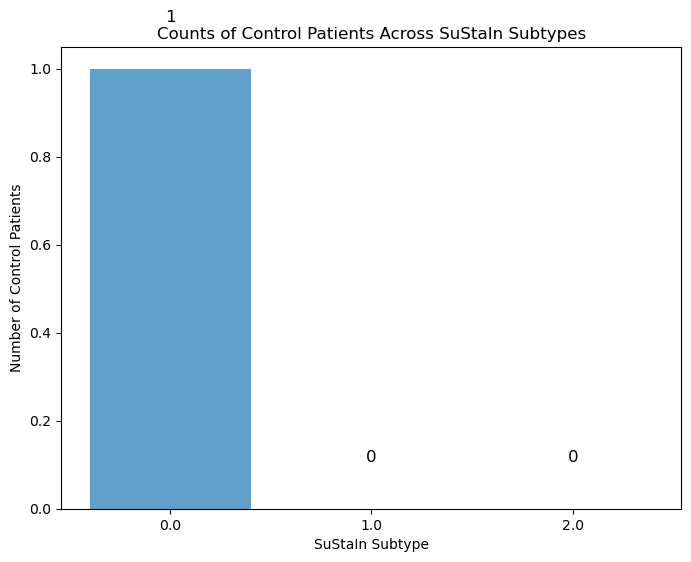

In [69]:
import matplotlib.pyplot as plt

# Drop rows with missing values
df_filtered = full_data_with_sustain.dropna(subset=["SuStaIn_subtype", "Pathologic Group"]).copy()

# Ensure ml_subtype is string
df_filtered["SuStaIn_subtype"] = df_filtered["SuStaIn_subtype"].astype(str)

# Filter for "control" in Pathologic Group
control_df = df_filtered[df_filtered["Pathologic Group"] == "Control"]

# Define all expected subtypes
all_subtypes = ["0.0", "1.0", "2.0"]

# Count control patients per subtype, fill 0 if missing
counts = [ (control_df["SuStaIn_subtype"] == s).sum() for s in all_subtypes ]

# Plot histogram
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10.colors
bars = plt.bar(all_subtypes, counts, color=[colors[i % len(colors)] for i in range(len(all_subtypes))], alpha=0.7)

# Annotate counts on top of each bar
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,  # small offset above the bar
        str(count),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.xlabel("SuStaIn Subtype")
plt.ylabel("Number of Control Patients")
plt.title("Counts of Control Patients Across SuStaIn Subtypes")


#save the figure
folder_name = os.path.basename(output_folder)

filename = f"Sustain_subtype_control_{folder_name}.png"
save_path = os.path.join(output_folder, filename)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

### Repeated Head impacts versus subtype 

In [70]:
import pandas as pd

# Filter rows where RHI Exposure is "Yes"
rhi_yes_df = full_data_with_sustain[
    full_data_with_sustain["RHI Exposure"].str.strip().str.capitalize() == "Yes"
].copy()

# Convert columns to numeric, coercing errors to NaN
rhi_yes_df["SuStaIn_subtype_numeric"] = pd.to_numeric(rhi_yes_df["SuStaIn_subtype"], errors="coerce")
rhi_yes_df["SuStaIn_stage_numeric"] = pd.to_numeric(rhi_yes_df["SuStaIn_stage"], errors="coerce")

# Drop rows where either subtype or stage is NaN
rhi_yes_cleaned = rhi_yes_df.dropna(subset=["SuStaIn_subtype_numeric", "SuStaIn_stage_numeric"]).copy()

# Display the cleaned table
#display(rhi_yes_cleaned[["SuStaIn_subtype", "SuStaIn_stage", "RHI Exposure"]])

# Optional: count numeric values (should equal number of rows now)
print(f"Number of RHI-positive subjects with numeric subtype and stage: {rhi_yes_cleaned.shape[0]}")


Number of RHI-positive subjects with numeric subtype and stage: 63


In [71]:
import pandas as pd

# Assuming rhi_yes_cleaned is your cleaned DataFrame
# Count RHI-positive subjects per subtype
rhi_counts_by_subtype = rhi_yes_cleaned.groupby("SuStaIn_subtype_numeric").size().reset_index(name="Count")

# Display the result
display(rhi_counts_by_subtype)

,SuStaIn_subtype_numeric,Count
0,0.0,24
1,1.0,24
2,2.0,15


### Count RHI Cases here

In [72]:
from scipy.stats import chi2_contingency

# Make a copy to avoid modifying original dataframe
df = full_data_with_sustain.copy()

# ----------------------------------------
# Ensure Football column is lowercase "yes"/"no"
# ----------------------------------------
df["Football"] = df["Football"].astype(str).str.strip().str.lower()

# ----------------------------------------
# Build Summary Table (RHI + Football)
# ----------------------------------------
rhi_counts = df.groupby("SuStaIn_subtype").agg(
    Total=("SuStaIn_subtype", "count"),

    # RHI Exposure (Yes/No)
    RHI_Exposure=("RHI Exposure", lambda x: (x.astype(str).str.strip().str.lower() == "yes").sum()),

    # Football exposure (YES = played football)
    Football_Exposure=("Football", lambda x: (x == "yes").sum())
).reset_index()

# ----------------------------------------
# Calculate exposure rates
# ----------------------------------------
rhi_counts["RHI_Exposure_Rate"] = rhi_counts["RHI_Exposure"] / rhi_counts["Total"] * 100
rhi_counts["Football_Rate"] = rhi_counts["Football_Exposure"] / rhi_counts["Total"] * 100

# ----------------------------------------
# Chi-square test FOR RHI (unchanged)
# ----------------------------------------
rhi_counts["No_Exposure"] = rhi_counts["Total"] - rhi_counts["RHI_Exposure"]
chi2_table = rhi_counts[["RHI_Exposure", "No_Exposure"]].copy()
chi2_table.index = rhi_counts["SuStaIn_subtype"]

chi2, p_chi2, dof, expected = chi2_contingency(chi2_table)
n_total = chi2_table.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(chi2_table.shape)-1)))

print(f"Chi-square (RHI): {chi2:.3f}, df={dof}, p-value={p_chi2:.4f}, Cramér's V={cramers_v:.3f}")

# ----------------------------------------
# Create melted dataframe for RHI plotting
# ----------------------------------------
rhi_melted = rhi_counts.melt(
    id_vars="SuStaIn_subtype",
    value_vars=["Total", "RHI_Exposure"],
    var_name="Category",
    value_name="Count"
)

# (Optional) Melt including Football if needed later:
rhi_melted_with_football = rhi_counts.melt(
    id_vars="SuStaIn_subtype",
    value_vars=["Total", "RHI_Exposure", "Football_Exposure"],
    var_name="Category",
    value_name="Count"
)

# ----------------------------------------
# Print updated summary table
# ----------------------------------------
print("\n Summary table with Football added:")
print(rhi_counts.head())


Chi-square (RHI): 5.762, df=2, p-value=0.0561, Cramér's V=0.152

 Summary table with Football added:
   SuStaIn_subtype  Total  RHI_Exposure  Football_Exposure  RHI_Exposure_Rate  \
0              0.0    126            24                 17          19.047619   
1              1.0     71            24                 19          33.802817   
2              2.0     51            15                 14          29.411765   

   Football_Rate  No_Exposure  
0      13.492063          102  
1      26.760563           47  
2      27.450980           36  


In [73]:
print(rhi_counts)

   SuStaIn_subtype  Total  RHI_Exposure  Football_Exposure  RHI_Exposure_Rate  \
0              0.0    126            24                 17          19.047619   
1              1.0     71            24                 19          33.802817   
2              2.0     51            15                 14          29.411765   

   Football_Rate  No_Exposure  
0      13.492063          102  
1      26.760563           47  
2      27.450980           36  


### Football or contact sports played vs subtype 

In [74]:
# correlation with contact sports played and subtype

In [75]:
# Work on a copy
df = full_data_with_sustain.copy()

# Standardize other contact sport column
df["Other_Contact_Sport"] = (
    df["Did the donor play a contact sport besides football?"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

# Convert football years to numeric (non-numeric → NaN)
df["Football_Years_Num"] = pd.to_numeric(
    df["Football: Total years played"], 
    errors="coerce"
)
# -----------------------------------------
# DEFINE SPORT EXPOSURE CORRECTLY
# -----------------------------------------
df["Sport_Exposure_Flag"] = (
    (df["Football_Years_Num"] > 0) | 
    (df["Other_Contact_Sport"] == "Yes")
)

# -----------------------------------------
# COUNT BY SUBTYPE — NO FILTERING
# -----------------------------------------
counts_df = df.groupby("SuStaIn_subtype").agg(
    Total=("SuStaIn_subtype", "count"),
    Sport_Exposure=("Sport_Exposure_Flag", "sum")
).reset_index()

counts_df["Exposure_Rate"] = counts_df["Sport_Exposure"] / counts_df["Total"] * 100
counts_df["No_Exposure"] = counts_df["Total"] - counts_df["Sport_Exposure"]

print(counts_df)


   SuStaIn_subtype  Total  Sport_Exposure  Exposure_Rate  No_Exposure
0              0.0    126              26      20.634921          100
1              1.0     71              25      35.211268           46
2              2.0     51              15      29.411765           36


## Analysis for Significance in the occurance of history of head trauma between subtypes

In [76]:
# Chi-square??
#A chi-square test evaluates whether these proportions differ more than you'd expect by chance.

# some concern here : If there’s reason to believe the clustering 
#indirectly used information correlated with head trauma, 
#a chi-square p-value might overstate the significance. 
#In that case, consider a permutation test or regression-based check.

### chi-squared calculation here

Chi-square: 5.198, df=2, p-value=0.0744, Cramér's V=0.145


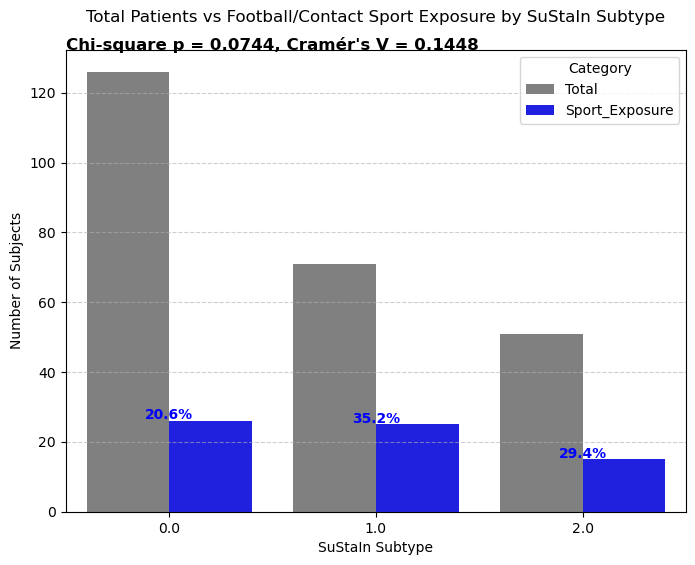

In [77]:
# Do the chi-square here:
from scipy.stats import chi2_contingency

# -------------------------------
# Calculate Exposure Rate
# -------------------------------
counts_df["Exposure_Rate"] = counts_df["Sport_Exposure"] / counts_df["Total"] * 100

# -------------------------------
# Chi-square Test
# -------------------------------
# Build contingency table: rows=subtypes, columns=[Yes, No]
contingency_table = counts_df[["SuStaIn_subtype", "Sport_Exposure", "Total"]].copy()
contingency_table["No_Exposure"] = contingency_table["Total"] - contingency_table["Sport_Exposure"]

chi2_table = contingency_table[["Sport_Exposure", "No_Exposure"]]
chi2_table.index = contingency_table["SuStaIn_subtype"]

chi2, p_chi2, dof, expected = chi2_contingency(chi2_table)
n_total = chi2_table.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(chi2_table.shape)-1)))

print(f"Chi-square: {chi2:.3f}, df={dof}, p-value={p_chi2:.4f}, Cramér's V={cramers_v:.3f}")


# Bar Chart with Exposure Rate & p-value annotation
# -------------------------------
counts_melted = counts_df.melt(
    id_vars="SuStaIn_subtype",
    value_vars=["Total", "Sport_Exposure"],
    var_name="Category",
    value_name="Count"
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=counts_melted,
    x="SuStaIn_subtype",
    y="Count",
    hue="Category",
    palette=["gray", "blue"]
)

plt.xlabel("SuStaIn Subtype")
plt.ylabel("Number of Subjects")
plt.title("Total Patients vs Football/Contact Sport Exposure by SuStaIn Subtype", pad=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Category")  # automatic labels

# Annotate bars with exposure rate
for i, row in counts_df.iterrows():
    plt.text(
        x=i,
        y=row["Sport_Exposure"] + 0.5,
        s=f"{row['Exposure_Rate']:.1f}%",
        ha='center',
        color='blue',
        fontweight='bold'
    )


# Annotate chi-square p-value and Cramér's V
annotation_text = f"Chi-square p = {p_chi2:.4f}, Cramér's V = {cramers_v:.4f}"

plt.text(
    x=0.5, y=rhi_counts["Total"].max() * 1.05,
    s=annotation_text,
    ha='center',
    fontsize=12,
    fontweight='bold'
)


# Save figure
folder_name = os.path.basename(output_folder)
filename = f"Subtype_total_vs_sport_exposure_withStats_{folder_name}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### More Detailed sport exposure v subtype analysis

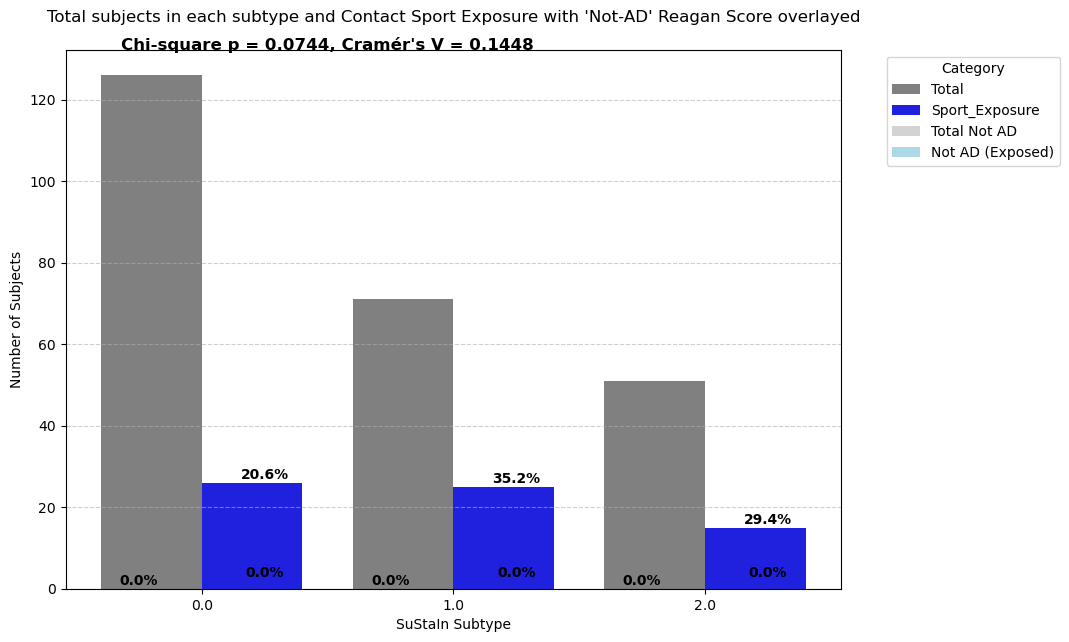

In [78]:
#some more data manipulation..
# Filter Not AD subjects
not_ad_df = df[df["NIA-Reagan Score"] == "Not AD"].copy()

# Total Not AD per subtype
not_ad_total = not_ad_df.groupby("SuStaIn_subtype").size()
not_ad_total = not_ad_total.reindex(counts_df["SuStaIn_subtype"], fill_value=0)
counts_df["Not_AD_Total"] = not_ad_total.values

# Not AD with sport exposure
not_ad_exposed = not_ad_df[not_ad_df["Sport_Exposure_Flag"]].groupby("SuStaIn_subtype").size()
not_ad_exposed = not_ad_exposed.reindex(counts_df["SuStaIn_subtype"], fill_value=0)
counts_df["Not_AD_Exposed"] = not_ad_exposed.values


plt.figure(figsize=(10, 7))

# Melt counts_df for base barplot (Total + Sport Exposure)
counts_melted = counts_df.melt(
    id_vars="SuStaIn_subtype",
    value_vars=["Total", "Sport_Exposure"],
    var_name="Category",
    value_name="Count"
)
sns.barplot(
    data=counts_melted,
    x="SuStaIn_subtype",
    y="Count",
    hue="Category",
    palette=["gray", "blue"],
    dodge=True
)

bar_width = 0.25
x_positions = np.arange(len(counts_df))

# Overlay Total Not AD on gray bar
plt.bar(
    x_positions - 0.25,
    counts_df["Not_AD_Total"],
    width=bar_width,
    label="Total Not AD",
    color="lightgray"
)

# Overlay Not AD exposed on blue bar
plt.bar(
    x_positions + 0.25,
    counts_df["Not_AD_Exposed"],
    width=bar_width,
    label="Not AD (Exposed)",
    color="#ADD8E6"  # light blue
)

# -------------------------------
# Annotate percentages
# -------------------------------
for i, row in counts_df.iterrows():
    # Exposure rate on blue bar
    exposure_pct = row["Sport_Exposure"] / row["Total"] * 100 if row["Total"] > 0 else 0
    plt.text(
        x=i + 0.25,
        y=row["Sport_Exposure"] + 1,
        s=f"{exposure_pct:.1f}%",
        ha='center',
        color='black',
        fontweight='bold'
    )

    # % Not AD in Total (orange bar)
    pct_not_ad_total = row["Not_AD_Total"] / row["Total"] * 100 if row["Total"] > 0 else 0
    plt.text(
        x=i - 0.25,
        y=row["Not_AD_Total"] + 1,
        s=f"{pct_not_ad_total:.1f}%",
        ha='center',
        color='black',
        fontweight='bold'
    )

    #% Not AD in Sport Exposure (light blue bar)
    pct_not_ad_exposed = row["Not_AD_Exposed"] / row["Sport_Exposure"] * 100 if row["Sport_Exposure"] > 0 else 0
    plt.text(
        x=i + 0.25,
        y=row["Not_AD_Exposed"] + 1 + 2,  # slight offset above light blue bar
        s=f"{pct_not_ad_exposed:.1f}%",
        ha='center',
        color='black',  # darker blue for contrast
        fontweight='bold'
    )

# Annotate chi-square p-value and Cramér's V
annotation_text = f"Chi-square p = {p_chi2:.4f}, Cramér's V = {cramers_v:.4f}"

plt.text(
    x=0.5, y=rhi_counts["Total"].max() * 1.05,
    s=annotation_text,
    ha='center',
    fontsize=12,
    fontweight='bold'
)

# -------------------------------
# Labels and legend
# -------------------------------
plt.xlabel("SuStaIn Subtype")
plt.ylabel("Number of Subjects")
plt.title("Total subjects in each subtype and Contact Sport Exposure with 'Not-AD' Reagan Score overlayed", pad=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(x_positions, counts_df["SuStaIn_subtype"])
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')

# -------------------------------
# Save figure
# -------------------------------
folder_name = os.path.basename(output_folder)
filename = f"Subtype_total_vs_sport_exposure_{folder_name}_{N_S_max}subtypes_likelihood_{high_prob}_{low_prob}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### Subtype v History of football played

Chi-square: 7.086, df=2, p-value=0.0289, Cramér's V=0.169


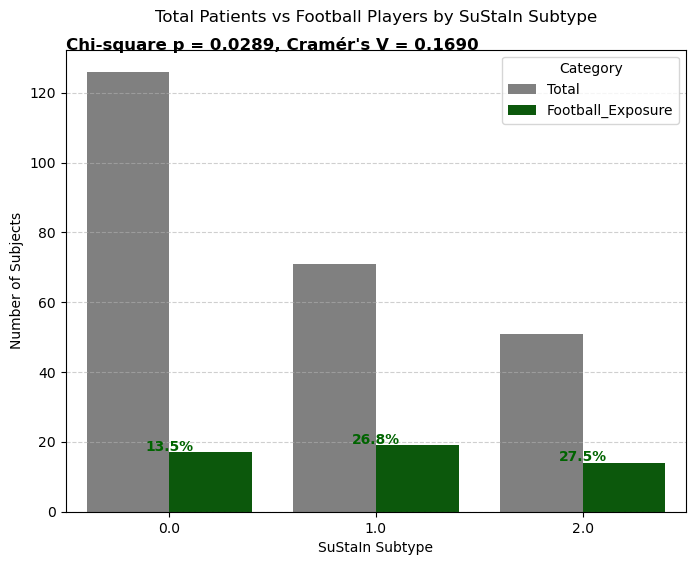

In [79]:
#adjusting here...

import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import chi2_contingency

# -----------------------------------------------
# Chi-Square Test: Football Yes vs No, across subtypes
# -----------------------------------------------
rhi_counts["No_Football"] = rhi_counts["Total"] - rhi_counts["Football_Exposure"]

chi2_table = rhi_counts[["Football_Exposure", "No_Football"]].copy()
chi2_table.index = rhi_counts["SuStaIn_subtype"]

chi2, p_chi2, dof, expected = chi2_contingency(chi2_table)
n_total = chi2_table.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(chi2_table.shape)-1)))

print(f"Chi-square: {chi2:.3f}, df={dof}, p-value={p_chi2:.4f}, Cramér's V={cramers_v:.3f}")

# -----------------------------------------------
# Melt table for plotting
# -----------------------------------------------
counts_melted = rhi_counts.melt(
    id_vars="SuStaIn_subtype",
    value_vars=["Total", "Football_Exposure"],
    var_name="Category",
    value_name="Count"
)

# -----------------------------------------------
# Bar Plot (Total vs Football Exposure)
# -----------------------------------------------
plt.figure(figsize=(8, 6))
sns.barplot(
    data=counts_melted,
    x="SuStaIn_subtype",
    y="Count",
    hue="Category",
    palette=["gray", "darkgreen"]
)

plt.xlabel("SuStaIn Subtype")
plt.ylabel("Number of Subjects")
plt.title("Total Patients vs Football Players by SuStaIn Subtype", pad=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Category")

# Annotate bars with Football exposure rate
for idx, row in rhi_counts.iterrows():
    plt.text(
        x=idx,
        y=row["Football_Exposure"] + 0.5,
        s=f"{row['Football_Rate']:.1f}%",
        ha='center',
        color='darkgreen',
        fontweight='bold'
    )

# Add Chi-square and Cramér’s V note
annotation_text = f"Chi-square p = {p_chi2:.4f}, Cramér's V = {cramers_v:.4f}"

plt.text(
    x=0.5,
    y=rhi_counts["Total"].max() * 1.05,
    s=annotation_text,
    ha='center',
    fontsize=12,
    fontweight='bold'
)

# Save figure
folder_name = os.path.basename(output_folder)
filename = f"Subtype_total_vs_football_exposure_withStats_{folder_name}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### years of contact sports played vs subtype assignment

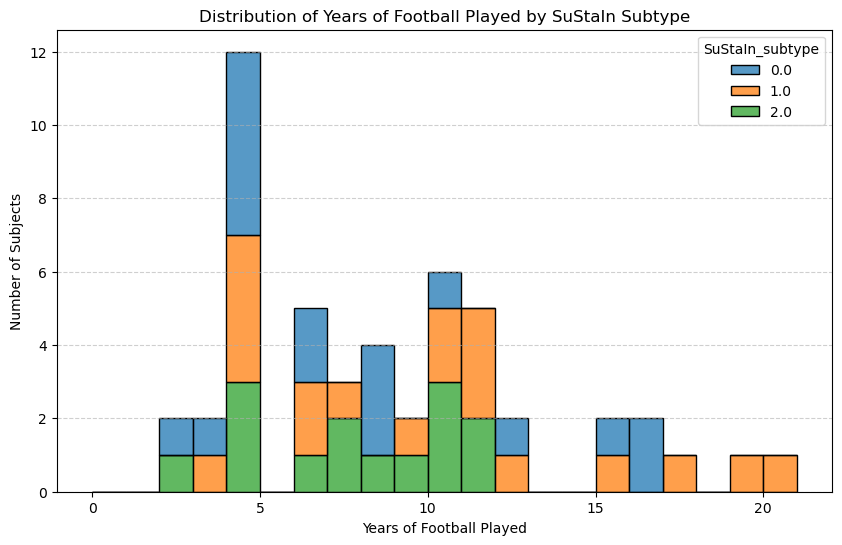

In [80]:
# Filter only rows with numeric football years
plot_df = full_data_with_sustain_cleaned.copy()
plot_df["Football_Years_Num"] = pd.to_numeric(plot_df["Football: Total years played"], errors="coerce")
plot_df = plot_df[plot_df["Football_Years_Num"].notna()].copy()

# -------------------------------
# Plot histogram
# -------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(
    data=plot_df,
    x="Football_Years_Num",
    hue="SuStaIn_subtype",
    multiple="stack",  # stack bars by subtype
    bins=range(0, int(plot_df["Football_Years_Num"].max()) + 2),  # 1-year bins
    palette="tab10"
)

plt.xlabel("Years of Football Played")
plt.ylabel("Number of Subjects")
plt.title("Distribution of Years of Football Played by SuStaIn Subtype")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


### Age versus stage and subtype

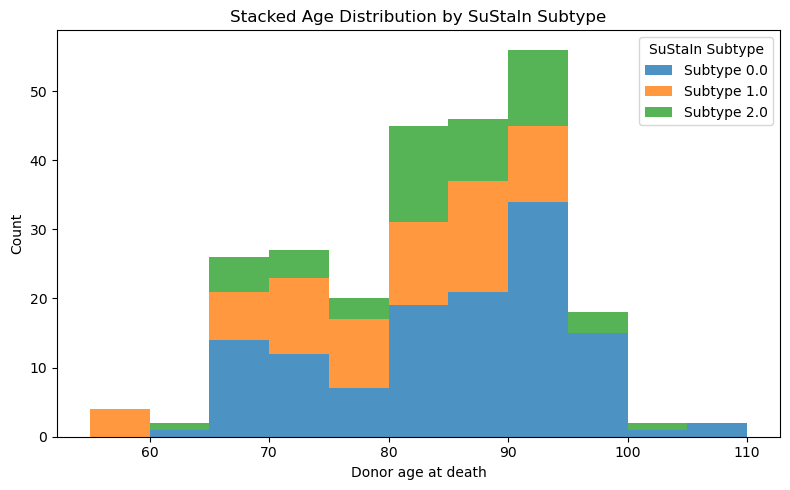

In [81]:
# 2 plots: either stage or subtype on the y axis age of the patient on the x 
# histogram for the counts 

# Dataframe
plot_df = full_data_with_sustain_cleaned.copy()

# Define age bins
age_bins = np.arange(
    plot_df['Donor age at death'].min(),
    plot_df['Donor age at death'].max() + 5,
    5
)

# Prepare data for stacking (SUBTYPES)
subtypes = sorted(plot_df['SuStaIn_subtype'].unique())
age_data = [
    plot_df.loc[plot_df['SuStaIn_subtype'] == subtype, 'Donor age at death']
    for subtype in subtypes
]

plt.figure(figsize=(8, 5))

plt.hist(
    age_data,
    bins=age_bins,
    stacked=True,
    label=[f"Subtype {subtype}" for subtype in subtypes],
    alpha=0.8
)

plt.xlabel("Donor age at death")
plt.ylabel("Count")
plt.title("Stacked Age Distribution by SuStaIn Subtype")
plt.legend(title="SuStaIn Subtype")
plt.tight_layout()
plt.show()


Subtype 0.0: average age = 84.90 years
Subtype 1.0: average age = 79.41 years
Subtype 2.0: average age = 83.31 years


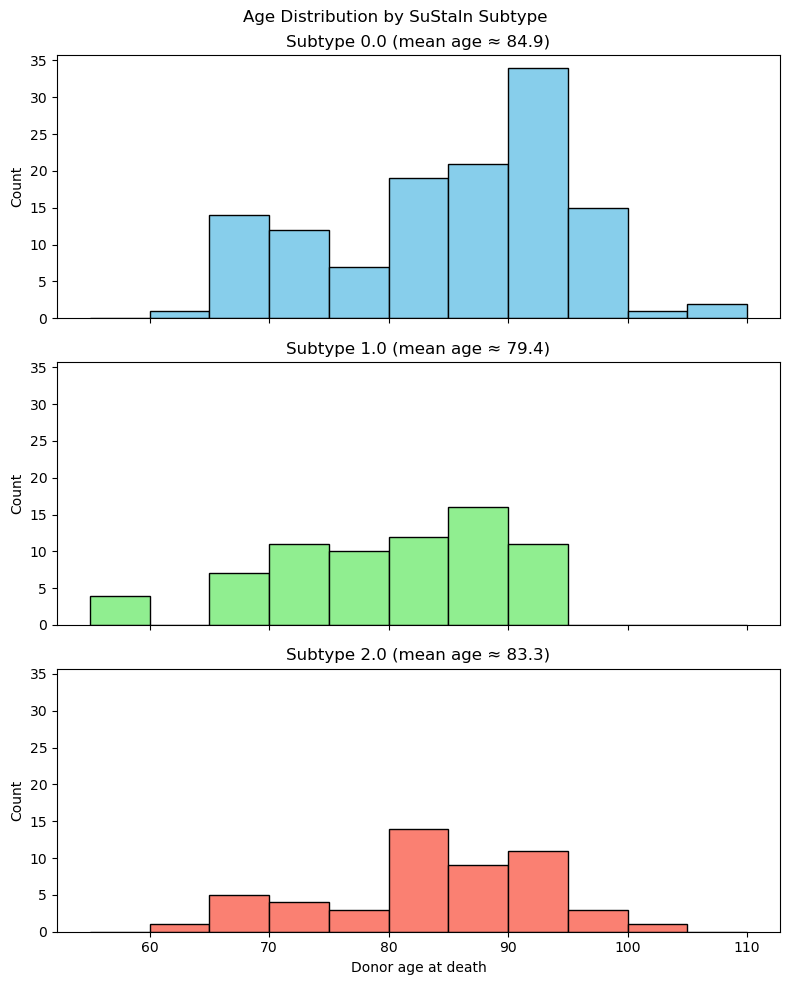

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Dataframe
plot_df = full_data_with_sustain_cleaned.copy()

# Define shared age bins
age_bins = np.arange(
    plot_df['Donor age at death'].min(),
    plot_df['Donor age at death'].max() + 5,
    5
)

# Get subtypes (assumes 3)
subtypes = sorted(plot_df['SuStaIn_subtype'].unique())

# Define colors for each histogram
colors = ['skyblue', 'lightgreen', 'salmon']  # adjust as needed

# Create stacked subplots (one column)
fig, axes = plt.subplots(
    nrows=len(subtypes),
    ncols=1,
    figsize=(8, 10),
    sharex=True,
    sharey=True
)

for ax, subtype, color in zip(axes, subtypes, colors):
    subset = plot_df.loc[
        plot_df['SuStaIn_subtype'] == subtype,
        'Donor age at death'
    ]
    
    ax.hist(
        subset,
        bins=age_bins,
        color=color,
        edgecolor='black'
    )
    
    mean_age = subset.mean()
    print(f"Subtype {subtype}: average age = {mean_age:.2f} years")
    
    ax.set_title(f"Subtype {subtype} (mean age ≈ {mean_age:.1f})")
    ax.set_ylabel("Count")

axes[-1].set_xlabel("Donor age at death")

fig.suptitle("Age Distribution by SuStaIn Subtype", y=.98)
plt.tight_layout()

# -------------------------------
# Save figure
# -------------------------------
folder_name = os.path.basename(output_folder)
filename = f"Age_v_subtype_{folder_name}_{N_S_max}subtypes_likelihood_{high_prob}_{low_prob}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### Scatter Age versus stage and subtype

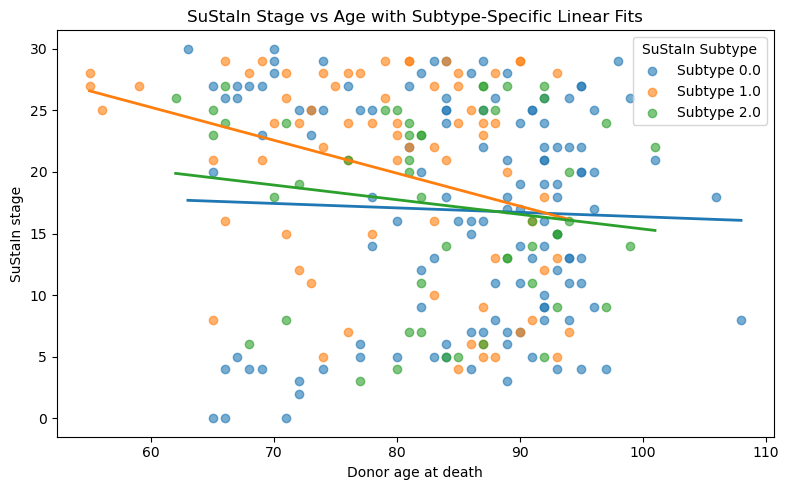

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Dataframe
plot_df = full_data_with_sustain_cleaned.copy()

# Get subtypes
subtypes = sorted(plot_df['SuStaIn_subtype'].unique())

plt.figure(figsize=(8, 5))

for subtype in subtypes:
    subset = plot_df[plot_df['SuStaIn_subtype'] == subtype]
    
    x = subset['Donor age at death']
    y = subset['SuStaIn_stage']
    
    # Scatter
    plt.scatter(
        x,
        y,
        alpha=0.6,
        label=f"Subtype {subtype}"
    )
    
    # Linear regression (1st-degree polynomial)
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        reg_line = np.poly1d(coeffs)
        
        x_fit = np.linspace(x.min(), x.max(), 100)
        plt.plot(x_fit, reg_line(x_fit), linewidth=2)

plt.xlabel("Donor age at death")
plt.ylabel("SuStaIn stage")
plt.title("SuStaIn Stage vs Age with Subtype-Specific Linear Fits")
plt.legend(title="SuStaIn Subtype")
plt.tight_layout()
plt.show()


### Hip total versus stage

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dataframe
plot_df = full_data_with_sustain_cleaned.copy()

plt.figure(figsize=(8, 5))

# Seaborn scatter + linear regression per subtype
sns.lmplot(
    data=plot_df,
    x='SuStaIn_stage',
    y='Hip Total',
    hue='SuStaIn_subtype',       # colors by subtype
    palette=['skyblue', 'lightgreen', 'salmon'],
    height=5,
    aspect=1.5,
    markers=['o', 's', 'D'],     # different marker per subtype
    scatter_kws={'alpha':0.7},
    ci=None                      # no confidence interval (simple regression)
)

plt.xlabel("SuStaIn stage")
plt.ylabel("Hip Total")
plt.title("Hip Total vs SuStaIn Stage by Subtype with Regression Lines")
plt.tight_layout()
plt.show()


### motor cortex and entorhinal cortex quantitaive values to see if they line up with the stages for external validation

In [ ]:
# Dataframe
import matplotlib.pyplot as plt

# Dataframe
plot_df = full_data_with_sustain_cleaned.copy()

regions = {
    "Motor Cortex": "Motor Cortex",
    "Entorhinal Cortex": "Ent cortex"   # <-- adjust if your column name differs
}

for title_name, col_name in regions.items():

    g = sns.lmplot(
        data=plot_df,
        x='SuStaIn_stage',
        y=col_name,
        hue='SuStaIn_subtype',
        palette=['skyblue', 'lightgreen', 'salmon'],
        height=5,
        aspect=1.5,
        markers=['o', 's', 'D'],
        scatter_kws={'alpha': 0.7},
        ci=None
    )

    g._legend.set_bbox_to_anchor((1.05, 0.5))
    
    plt.xlabel("SuStaIn stage")
    plt.ylabel(col_name)
    plt.title(f"{title_name} Total Quantitative Tau Burden vs SuStaIn Stage by Subtype")
    plt.tight_layout()

    
    # -------------------------------
    # Save figure
    # -------------------------------
    folder_name = os.path.basename(output_folder)
    filename = f"Quantitative_Biomarker_{title_name}_vStage.png"
    save_path = os.path.join(output_folder, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# now group all of the folks into 3 subgroups for each of 9 subtypes:
# stage 1-10, 11-20, 21-30
# get the average age of each of these interval of stages for each subtype 
# plot the stage range on the x and averaeg age on the y with colors showing different subtypes

import pandas as pd
import matplotlib.pyplot as plt


# Copy dataframe
df = full_data_with_sustain_cleaned.copy()

# Define stage bins for 9 intervals
# Example: 1-3, 4-6, 7-9, ..., 25-27, 28-30
stage_bins = [0, 3, 6, 9, 12, 15, 18, 21, 24, 30]
stage_labels = ['1-3', '4-6', '7-9', '10-12', '13-15', '16-18', '19-21', '22-24', '25-30']

df['Stage_bin'] = pd.cut(
    df['SuStaIn_stage'],
    bins=stage_bins,
    labels=stage_labels,
    include_lowest=True
)

# Group by subtype and stage bin, compute average age
avg_age_df = df.groupby(['SuStaIn_subtype', 'Stage_bin'])['Donor age at death'].mean().reset_index()

# Plot
plt.figure(figsize=(12,5))

subtypes = sorted(df['SuStaIn_subtype'].unique())
colors = ['skyblue', 'lightgreen', 'salmon']  # adjust if you have more subtypes

for subtype, color in zip(subtypes, colors):
    subset = avg_age_df[avg_age_df['SuStaIn_subtype'] == subtype]
    
    plt.plot(
        subset['Stage_bin'],
        subset['Donor age at death'],
        marker='o',
        color=color,
        label=f"Subtype {subtype}"
    )

plt.xlabel("SuStaIn stage range")
plt.ylabel("Average Donor Age at Death")
plt.title("Average Age by Stage Range and Subtype (9 bins)")
plt.legend(title="SuStaIn Subtype")
plt.xticks(rotation=45)
plt.tight_layout()

# -------------------------------
# Save figure
# -------------------------------
folder_name = os.path.basename(output_folder)
filename = f"Age_v_stageRange_{folder_name}_{N_S_max}subtypes_likelihood_{high_prob}_{low_prob}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### Box and whisker for age and stage

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Copy dataframe
df = full_data_with_sustain_cleaned.copy()

# Define stage bins for 9 intervals
stage_bins = [0, 3, 6, 9, 12, 15, 18, 21, 24, 30]
stage_labels = ['1-3', '4-6', '7-9', '10-12', '13-15', '16-18', '19-21', '22-24', '25-30']

df['Stage_bin'] = pd.cut(
    df['SuStaIn_stage'],
    bins=stage_bins,
    labels=stage_labels,
    include_lowest=True
)

# Plot boxplots
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x='Stage_bin',
    y='Donor age at death',
    hue='SuStaIn_subtype',
    palette=['skyblue', 'lightgreen', 'salmon']
)

plt.xlabel("SuStaIn Stage Range")
plt.ylabel("Donor Age at Death")
plt.title("Age Distribution by Stage Range and Subtype (Boxplots)")
plt.legend(title="SuStaIn Subtype", loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
# Save figure
# -------------------------------
folder_name = os.path.basename(output_folder)
filename = f"Age_distribution_byStage_{folder_name}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()



### Summary Table

In [ ]:
# here we want to summarize the three subtypes
# make three rows for each subtype with the following counts
# percent male, percent female, age, total exposure, average football years played, Hip total (average), % in stage 1-6, 
# % in stage 7-12, % in stage 13-18, % in stage 19-24, % in stage 25-30

In [ ]:
import pandas as pd
import numpy as np

# Copy dataframe
df = full_data_with_sustain_cleaned.copy()

# Define stage bins for percentages
stage_bins = [0, 6, 12, 18, 24, 30]  # Stage intervals
stage_labels = ['1-6', '7-12', '13-18', '19-24', '25-30']

df['Stage_bin'] = pd.cut(
    df['SuStaIn_stage'],
    bins=stage_bins,
    labels=stage_labels,
    include_lowest=True
)

# Initialize list to store subtype summaries
summary_list = []

subtypes = sorted(df['SuStaIn_subtype'].unique())

for subtype in subtypes:
    subset = df[df['SuStaIn_subtype'] == subtype]
    total_n = len(subset)
    
    percent_male = (subset['gender'] == 'Male').mean() * 100
    percent_female = (subset['gender'] == 'Female').mean() * 100
    avg_age = subset['Donor age at death'].mean()
    avg_years_played = subset['Football: Total years played'].mean()
    hip_total_avg = subset['Hip Total'].mean()
    
    # Percentage of cases in each stage bin
    stage_counts = subset['Stage_bin'].value_counts(normalize=True).reindex(stage_labels, fill_value=0) * 100
    
    summary_list.append({
        'Subtype': subtype,
        '% Male': percent_male,
        '% Female': percent_female,
        'Avg Age': avg_age,
        'Avg Football Years': avg_years_played,
        'Hip Total Avg': hip_total_avg,
        '% Stage 1-6': stage_counts['1-6'],
        '% Stage 7-12': stage_counts['7-12'],
        '% Stage 13-18': stage_counts['13-18'],
        '% Stage 19-24': stage_counts['19-24'],
        '% Stage 25-30': stage_counts['25-30']
    })


# Convert to DataFrame
subtype_summary_df = pd.DataFrame(summary_list)

# Round all numeric columns to one decimal place
subtype_summary_df = subtype_summary_df.round(1)

# Display the table
subtype_summary_df


### Stage probability versus Assigned stage

In [ ]:
## Take a look at the relationship between assigned stage and stage probability 
# plot stage probability on y and assigned stage on x. 
# we want to see if the confidence in assignment varies at all 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Copy dataframe
df = full_data_with_sustain_cleaned.copy()

# Define stage bins
stage_bins = [0, 6, 12, 18, 24, 30]
stage_labels = ['1–6', '7–12', '13–18', '19–24', '25–30']

df['Stage_bin'] = pd.cut(
    df['SuStaIn_stage'],
    bins=stage_bins,
    labels=stage_labels,
    include_lowest=True
)

plt.figure(figsize=(8, 6))
ax = plt.gca()

# Loop through subtypes
for subtype in sorted(df['SuStaIn_subtype'].unique()):
    sub_df = df[df['SuStaIn_subtype'] == subtype]
    
    mean_prob = (
        sub_df
        .groupby('Stage_bin')['SuStaIn_stage_prob']
        .mean()
        .reindex(stage_labels)
    )
    
    x = np.arange(len(stage_labels))
    y = mean_prob.values
    
    ax.plot(
        x,
        y,
        marker='o',
        linewidth=2,
        label=f"Subtype {subtype}"
    )
    
    # Linear trend across bins
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        m, b = np.polyfit(x[valid], y[valid], 1)
        ax.plot(
            x,
            m * x + b,
            linestyle='--',
            alpha=0.6
        )


# Axis labels and ticks
ax.set_xticks(np.arange(len(stage_labels)))
ax.set_xticklabels(stage_labels)
ax.set_xlabel("Assigned SuStaIn Stage (binned)")
ax.set_ylabel("Mean Stage Probability")
ax.set_title("SuStaIn Stage Assignment Confidence by Stage Bin")
ax.set_ylim(0, 1.0)

# Make grid twice as frequent
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Grid styling
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

ax.legend(title="Subtype")
plt.tight_layout()


# Save figure
# -------------------------------
folder_name = os.path.basename(output_folder)
filename = f"Sustain_Stage_assignmentProbability_v_Stage_{folder_name}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


### Subtype probability versus Assigned stage

In [ ]:
# pretty decent sanity check on the sustain output here. 
# were trying to see if the assignment to subtype is weaker for less pahtologically obvious patients

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Copy dataframe
df = full_data_with_sustain_cleaned.copy()

# Number of subtypes
n_subtypes = df['SuStaIn_subtype'].nunique()
chance_level = 1 / n_subtypes

# Define stage bins
stage_bins = [0, 6, 12, 18, 24, 30]
stage_labels = ['1–6', '7–12', '13–18', '19–24', '25–30']

df['Stage_bin'] = pd.cut(
    df['SuStaIn_stage'],
    bins=stage_bins,
    labels=stage_labels,
    include_lowest=True
)

plt.figure(figsize=(8, 6))
ax = plt.gca()

# Loop through subtypes
for subtype in sorted(df['SuStaIn_subtype'].unique()):
    sub_df = df[df['SuStaIn_subtype'] == subtype]
    
    # Mean assigned subtype probability per stage bin
    mean_prob = (
        sub_df
        .groupby('Stage_bin')['SuStaIn_subtype_prob']
        .mean()
        .reindex(stage_labels)
    )
    
    x = np.arange(len(stage_labels))
    y = mean_prob.values
    
    ax.plot(
        x,
        y,
        marker='o',
        linewidth=2,
        label=f"Subtype {subtype}"
    )
    
    # Linear trend line
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        m, b = np.polyfit(x[valid], y[valid], 1)
        ax.plot(
            x,
            m * x + b,
            linestyle='--',
            alpha=0.6
        )

# Chance-level reference line
ax.axhline(
    chance_level,
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    label=f'Chance level ({chance_level:.2f})'
)

# Axis labels and formatting
ax.set_xticks(np.arange(len(stage_labels)))
ax.set_xticklabels(stage_labels)
ax.set_xlabel("Assigned SuStaIn Stage (binned)")
ax.set_ylabel("Assigned Subtype Probability")
ax.set_title("Assigned Subtype Probability vs Disease Stage")
ax.set_ylim(0, 1.0)

# Denser grid
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

ax.legend(title="Assigned Subtype")
plt.tight_layout()


# Save figure
# -------------------------------
folder_name = os.path.basename(output_folder)
filename = f"Sustain_Subtype_assignmentProbability_v_Stage_{folder_name}.png"
save_path = os.path.join(output_folder, filename)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()